In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
import json

# ── Output accumulators ────────────────────────────────────────────────────────
gcs_    = pd.DataFrame()
ngs_    = pd.DataFrame()
others_ = pd.DataFrame()
all_    = pd.DataFrame()

cache_dir = '/Users/harryclark/Documents/spatial-manifolds/data/behavioural_influence_cache'
os.makedirs(cache_dir, exist_ok=True)

mouse_days = {
    20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
    21: [15,16,17,18,19,20,21,22,23,24,25,26],
    22: [33,34,35,36,37,38,39,40,41],
    25: [16,17,18,19,20,21,22,23,24,25],
    26: [11,12,13,14,15,16,17,18,19],
    27: [16,17,18,19,20,21,22,23,24,26],
    28: [16,17,18,19,20,21,22,23,25],
    29: [16,17,18,19,20,21,22,23,25],
}

def _safe_read_csv(path):
    """Read a CSV, returning an empty DataFrame for empty/missing files."""
    try:
        return pd.read_csv(path)
    except (pd.errors.EmptyDataError, FileNotFoundError):
        return pd.DataFrame()

def _percentage_hits(trial_types, trial_performances, task_anchored_labels, trial_type, task_label):
    mask  = (trial_types == trial_type) & (task_anchored_labels == task_label)
    hits  = np.sum(trial_performances[mask] == 'hit')
    total = np.sum(mask)
    return 100 * hits / total if total > 0 else np.nan

def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

for mouse, days in mouse_days.items():
    for day in days:

        # ── Cache check ───────────────────────────────────────────────────────
        cache_file = os.path.join(cache_dir, f'M{mouse}_D{day:02d}.csv')

        if os.path.exists(cache_file):
            print(f"M{mouse} D{day:02d}: loading from cache.")
            df = _safe_read_csv(cache_file)
            if len(df) > 0 and 'cell_identity' in df.columns:
                gcs_    = pd.concat([gcs_,    df[df.cell_identity == 'GC']], ignore_index=True)
                ngs_    = pd.concat([ngs_,    df[df.cell_identity.isin(['NGS-ramp', 'NGS-nonramp'])]], ignore_index=True)
                others_ = pd.concat([others_, df[df.cell_identity == 'NS']], ignore_index=True)
                all_    = pd.concat([all_,    df], ignore_index=True)
            continue

        print(f"Processing M{mouse} D{day:02}...")

        gcs, ngs, all_cells = classify_cells_both_sessions(
            mouse, day, percentile_threshold=95, source_path=None, verbose=False,
        )
        others = all_cells[~all_cells.index.isin(gcs.index) & ~all_cells.index.isin(ngs.index)]

        gcs    = gcs.copy();    gcs['cell_type']    = 'GC'
        ngs    = ngs.copy();    ngs['cell_type']    = 'NG'
        others = others.copy(); others['cell_type'] = 'Other'

        for cells in [gcs, ngs, others]:
            cells['mouse'] = mouse
            cells['day']   = day

        # determine which NGS cluster_ids are also VR ramp cells
        ramp_ids = set()
        try:
            rc, _, _ = cell_classification_vr(mouse, day)
            if len(rc) > 0:
                ramp_ids = set(int(x) for x in rc.cluster_id.values)
        except Exception as e:
            print(f"  VR ramp classification failed for M{mouse} D{day:02}: {e}")

        tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse, day, apply_zscore=False, apply_guassian_filter=False)

        last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
        ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')
        speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units='ms', ep=ep))
        dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep) - ((beh['trial_number'][0]-1)*tl))
        pos_in_time = dt_in_time % tl
        trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]

        if np.any(np.isnan(pos_in_time)):
            dt_in_time = np.array(pd.Series(dt_in_time).ffill().bfill())
            pos_in_time = dt_in_time % tl
            trial_number_in_time = (dt_in_time // tl) + beh['trial_number'][0]
        if np.any(np.isnan(speed_in_time)):
            speed_in_time = np.array(pd.Series(speed_in_time).ffill().bfill())

        last_trial         = int(last_ephys_bin / (tl / bs))
        trial_types        = beh['trials'].type[:last_trial].values
        trial_performances = beh['trials'].performance[:last_trial].values
        peak_indices       = [12, 28, 44, 60, 76]

        # ── Unified cell loop ─────────────────────────────────────────────────
        combined = pd.concat([gcs, ngs, others], ignore_index=True)

        for idx in range(len(combined)):
            example_cluster_id = combined.loc[idx, 'cluster_id']
            cell_type          = combined.loc[idx, 'cell_type']
            print(f"\nMouse: {mouse}, Day: {day}, Cluster: {example_cluster_id} ({cell_type})")

            if example_cluster_id not in tcs:
                continue

            tcs_to_use = {example_cluster_id: tcs[example_cluster_id]}
            tcs_to_use[1000] = tcs_to_use[example_cluster_id].copy()
            tcs_to_use[1000]               += np.random.normal(0.0, 0.001, size=tcs_to_use[1000].shape)
            tcs_to_use[example_cluster_id] += np.random.normal(0.0, 0.001, size=tcs_to_use[example_cluster_id].shape)

            try:
                results      = spectral_analysis(tcs_to_use, tl, bs=bs)
                spectrograms = results[3]
                S            = spectrograms.mean(0)
                max_peaks    = np.argmax(S, axis=0)
                labels       = np.isin(max_peaks, peak_indices).astype(int)
            except Exception as e:
                print(f"  spectral_analysis failed: {e}")
                continue

            tc = tcs[example_cluster_id]
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            task_anchored_labels = get_kmeans_spatial_labels(tc, labels, bs=bs, tl=tl)

            combined.loc[idx, 'pct_b_1']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  1)
            combined.loc[idx, 'pct_nb_1']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 1)
            combined.loc[idx, 'pct_b_0']              = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'b',  0)
            combined.loc[idx, 'pct_nb_0']             = _percentage_hits(trial_types, trial_performances, task_anchored_labels, 'nb', 0)
            combined.loc[idx, 'task_anchored_labels'] = json.dumps(task_anchored_labels.tolist())

        # Re-split by cell_type for cell_identity assignment
        gcs    = combined[combined.cell_type == 'GC'].copy().reset_index(drop=True)
        ngs    = combined[combined.cell_type == 'NG'].copy().reset_index(drop=True)
        others = combined[combined.cell_type == 'Other'].copy().reset_index(drop=True)

        # ── Assign cell_identity, save unified cache, accumulate ──────────────
        gcs['cell_identity']    = 'GC'
        gcs['shuffled']         = False
        ngs['cell_identity']    = ngs.cluster_id.apply(
            lambda cid: 'NGS-ramp' if int(cid) in ramp_ids else 'NGS-nonramp'
        )
        ngs['shuffled']         = False
        others['cell_identity'] = 'NS'
        others['shuffled']      = False

        session_df = pd.concat([gcs, ngs, others], ignore_index=True)
        session_df.to_csv(cache_file, index=False)
        print(f"  M{mouse} D{day:02d}: cached to {cache_dir}")

        gcs_    = pd.concat([gcs_,    gcs],        ignore_index=True)
        ngs_    = pd.concat([ngs_,    ngs],        ignore_index=True)
        others_ = pd.concat([others_, others],     ignore_index=True)
        all_    = pd.concat([all_,    session_df], ignore_index=True)

print(f'there are this many cells at the moment, {len(all_)}')
print(f'there are this many gcs at the moment, {len(gcs_)}')
print(f'there are this many ngs at the moment, {len(ngs_)}')
print(f'there are this many others at the moment, {len(others_)}')


M20 D14: loading from cache.
M20 D15: loading from cache.
M20 D16: loading from cache.
M20 D17: loading from cache.
M20 D18: loading from cache.
M20 D19: loading from cache.
M20 D20: loading from cache.
M20 D21: loading from cache.
M20 D22: loading from cache.
M20 D23: loading from cache.
M20 D24: loading from cache.
M20 D25: loading from cache.
M20 D26: loading from cache.
M21 D15: loading from cache.
M21 D16: loading from cache.
M21 D17: loading from cache.
M21 D18: loading from cache.
M21 D19: loading from cache.
M21 D20: loading from cache.
M21 D21: loading from cache.
M21 D22: loading from cache.
M21 D23: loading from cache.
M21 D24: loading from cache.
M21 D25: loading from cache.
M21 D26: loading from cache.
M22 D33: loading from cache.
M22 D34: loading from cache.
M22 D35: loading from cache.
M22 D36: loading from cache.
M22 D37: loading from cache.
M22 D38: loading from cache.
M22 D39: loading from cache.
M22 D40: loading from cache.
M22 D41: loading from cache.
M25 D16: loadi

In [3]:
# NGS sub-classification is already encoded in cell_identity from the main loop.
ngs_ramp_    = ngs_[ngs_.cell_identity == 'NGS-ramp'].reset_index(drop=True)
ngs_nonramp_ = ngs_[ngs_.cell_identity == 'NGS-nonramp'].reset_index(drop=True)

print(f'{len(ngs_ramp_)} NGS-ramp cells  ({len(ngs_)} NGS total)')
print(f'{len(ngs_nonramp_)} NGS-non-ramp cells')


1513 NGS-ramp cells  (6014 NGS total)
4501 NGS-non-ramp cells


In [4]:
all_

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,firing_rate_VR,classified_by,cell_type,pct_b_1,pct_nb_1,pct_b_0,pct_nb_0,task_anchored_labels,cell_identity,shuffled
0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,NaN,...,0.581641,OF2,GC,81.818182,23.255814,84.210526,25.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",GC,False
1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,NaN,...,5.677688,OF2,GC,91.549296,29.508197,68.421053,18.518519,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",GC,False
2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,NaN,...,0.455482,OF2,GC,77.777778,9.523810,84.000000,27.659574,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",GC,False
3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,NaN,...,7.255491,OF1,GC,92.857143,27.272727,80.246914,23.655914,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",GC,False
4,37,ENTm1,-0.716572,26.094122,34.792162,10.002436,1.5,2,False,NaN,...,1.472944,OF1,NG,80.000000,14.285714,83.653846,25.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NGS-ramp,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8922,550,ENTm5,-0.111145,18.568656,24.758209,4.706601,1.5,7,False,NaN,...,1.722614,NaN,Other,84.782609,82.608696,85.106383,76.744186,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NS,False
8923,552,ENTm5,-0.255859,37.339592,49.786123,5.587589,1.5,7,False,NaN,...,8.914767,NaN,Other,85.937500,76.785714,82.758621,84.848485,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NS,False
8924,553,ENTm5,0.745899,50.170017,66.893356,55.679758,1.5,7,True,NaN,...,6.210453,NaN,Other,91.176471,79.310345,68.000000,80.645161,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NS,False
8925,554,ENTm5,-0.193868,33.850811,45.134414,28.797167,1.5,7,False,NaN,...,3.037416,NaN,Other,84.313725,81.132075,85.714286,77.777778,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NS,False


## Shuffle control group — label shift

The shuffle null distribution is generated by **cyclically shifting the `task_anchored_labels` vector** for each cell. This preserves the exact number of task-anchored and non-task-anchored trials but randomises their temporal assignment to the trial sequence.

### How it works

1. **Load stored labels.**  
   Each cell's `task_anchored_labels` — a 1-D integer array of length `n_trials` (0 = non-task-anchored, 1 = task-anchored) — is read directly from the main analysis cache. No tuning-curve computation or spectral analysis is required.

2. **Draw a random shift.**  
   A shift amount is sampled uniformly from the integer interval $[\lfloor 0.2 \times n_\text{trials} \rfloor,\; \lfloor 0.8 \times n_\text{trials} \rfloor)$. The 20 %–80 % bounds ensure the shift is never trivially small and never nearly a full rotation. Sensitivity to this choice is tested in the extended figure (see below).

3. **Cyclic shift.**  
   `np.roll(task_anchored_labels, shift)` moves the label vector forward by `shift` positions, wrapping around the end.

4. **Recompute hit percentages.**  
   The shifted labels are combined with the unchanged `trial_types` and `trial_performances` vectors to compute `pct_b_1`, `pct_nb_1`, `pct_b_0`, and `pct_nb_0` exactly as for the real cells.

Cache files: `M{mouse}_D{day:02d}_shuffled_labelshift.csv`


In [5]:

# ── Build label-shift shuffle control group ───────────────────────────────────
# For each cell, cyclically shift its stored task_anchored_labels by a random
# number of trials drawn uniformly from [20%, 80%] of total trials, then
# recompute hit percentages. No spectral analysis needed.
#
# Cache files: M{mouse}_D{day:02d}_shuffled_labelshift.csv

shuffled_  = pd.DataFrame()
n_pos_bins = int(tl / bs)

for mouse, days in mouse_days.items():
    for day in days:

        shuf_cache = os.path.join(cache_dir, f'M{mouse}_D{day:02d}_shuffled_labelshift.csv')

        if os.path.exists(shuf_cache):
            print(f"M{mouse} D{day:02d}: loading label-shift shuffle from cache.")
            _shuf_cached = _safe_read_csv(shuf_cache)
            if len(_shuf_cached) > 0 and 'cell_identity' in _shuf_cached.columns:
                shuffled_ = pd.concat([shuffled_, _shuf_cached], ignore_index=True)
            continue

        print(f"Computing label-shift shuffle M{mouse} D{day:02d}...")

        session_df = all_[(all_.mouse == mouse) & (all_.day == day)].reset_index(drop=True)
        if len(session_df) == 0:
            print(f"  No cells in all_ for M{mouse} D{day:02d}, skipping.")
            continue

        try:
            _, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  compute_vr_tcs failed: {e}")
            continue

        last_trial         = int(last_ephys_bin / (tl / bs))
        trial_types        = beh['trials'].type[:last_trial].values
        trial_performances = beh['trials'].performance[:last_trial].values

        session_rows = []
        for _, cell_row in session_df.iterrows():
            orig_json = cell_row.get('task_anchored_labels')
            if pd.isna(orig_json):
                continue

            orig_labels = np.array(json.loads(orig_json))
            n_trials    = len(orig_labels)
            lo          = max(1, int(0.2 * n_trials))
            hi          = max(lo + 1, int(0.8 * n_trials))
            shift       = np.random.randint(lo, hi)
            shifted     = np.roll(orig_labels, shift)

            row_data = cell_row.to_dict()
            row_data['shuffled']             = True
            row_data['task_anchored_labels'] = json.dumps(shifted.tolist())
            row_data['pct_b_1']              = _percentage_hits(trial_types, trial_performances, shifted, 'b',  1)
            row_data['pct_nb_1']             = _percentage_hits(trial_types, trial_performances, shifted, 'nb', 1)
            row_data['pct_b_0']              = _percentage_hits(trial_types, trial_performances, shifted, 'b',  0)
            row_data['pct_nb_0']             = _percentage_hits(trial_types, trial_performances, shifted, 'nb', 0)
            session_rows.append(row_data)

        if session_rows:
            df_session = pd.DataFrame(session_rows)
            df_session.to_csv(shuf_cache, index=False)
            shuffled_ = pd.concat([shuffled_, df_session], ignore_index=True)
            print(f"  M{mouse} D{day:02d}: {len(df_session)} label-shift cells cached.")
        else:
            pd.DataFrame({'_empty': [1]}).to_csv(shuf_cache, index=False)

print(f"Label-shift shuffle: {len(shuffled_)} total cells")


M20 D14: loading label-shift shuffle from cache.
M20 D15: loading label-shift shuffle from cache.
M20 D16: loading label-shift shuffle from cache.
M20 D17: loading label-shift shuffle from cache.
M20 D18: loading label-shift shuffle from cache.
M20 D19: loading label-shift shuffle from cache.
M20 D20: loading label-shift shuffle from cache.
M20 D21: loading label-shift shuffle from cache.
M20 D22: loading label-shift shuffle from cache.
M20 D23: loading label-shift shuffle from cache.
M20 D24: loading label-shift shuffle from cache.
M20 D25: loading label-shift shuffle from cache.
M20 D26: loading label-shift shuffle from cache.
M21 D15: loading label-shift shuffle from cache.
M21 D16: loading label-shift shuffle from cache.
M21 D17: loading label-shift shuffle from cache.
M21 D18: loading label-shift shuffle from cache.
M21 D19: loading label-shift shuffle from cache.
M21 D20: loading label-shift shuffle from cache.
M21 D21: loading label-shift shuffle from cache.
M21 D22: loading lab


Beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1335    Method:             ML        
No. Groups:        8       Scale:              91.8150   
Min. group size:   22      Log-Likelihood:     -5018.9052
Max. group size:   351     Converged:          Yes       
Mean group size:   166.9                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      79.101    1.740 45.448 0.000 75.689 82.512
C(label)[T.1]   1.689    0.527  3.208 0.001  0.657  2.721
cluster Var     0.197                                    
day Var       180.117    2.559                           


Non-beaconed: mixed model summary
          Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: pct_hits  
No. Observations:  1382  

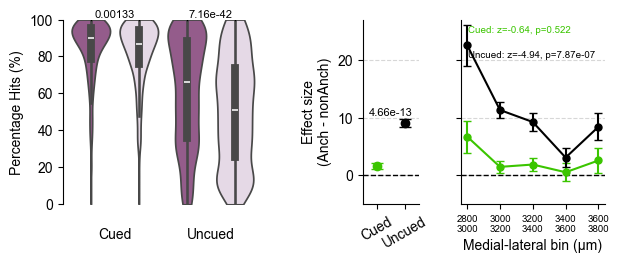

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Build long-form DataFrame for seaborn and mixed models
records = []
for _, row in gcs_.iterrows():
    for trial_type in ['b', 'nb']:
        for label in [0, 1]:
            col = f'pct_{trial_type}_{label}'
            if col not in row or pd.isna(row[col]):
                continue
            records.append({
                'pct_hits': row[col],
                'trial_type': trial_type,
                'label': label,
                'condition': f'{trial_type}, label={label}',
                'mouse': row.get('mouse', np.nan),
                'day': row.get('day', np.nan),
                'cluster_id': row.get('cluster_id', np.nan),
            })

df_plot = pd.DataFrame.from_records(records)

# Ensure categorical ordering: b,label=1; b,label=0; nb,label=1; nb,label=0
order = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
df_plot['condition'] = pd.Categorical(df_plot['condition'], categories=order, ordered=True)

# Color mapping: label 0 -> #e7d7e8, label 1 -> #9d5391
palette = {
    'b, label=0':  '#e7d7e8',
    'b, label=1':  '#9d5391',
    'nb, label=0': '#e7d7e8',
    'nb, label=1': '#9d5391',
}

# Colors for Cued / Uncued
trial_colors = {'Cued': '#3bc500', 'Uncued': 'black'}

# ----- Mixed models for comparisons within beaconed and non-beaconed -----
p_b = np.nan
p_nb = np.nan
eff_b = np.nan
eff_nb = np.nan
se_b = np.nan
se_nb = np.nan

def fit_lmm_trialtype(df_subset, trial_label):
    df_mod = df_subset.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
    if df_mod['label'].nunique() < 2:
        print(f"{trial_label}: not enough data for both labels")
        return np.nan, np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={
                'day': '0 + C(day)',
                'cluster': '0 + C(cluster_id)',
            },
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{trial_label}: mixed model summary")
        print(m_fit.summary())

        term = 'C(label)[T.1]'
        pval = m_fit.pvalues.get(term, np.nan)
        effect = m_fit.params.get(term, np.nan)

        cov = m_fit.cov_params()
        if term in cov.index:
            se = np.sqrt(cov.loc[term, term])
        else:
            se = np.nan

        return pval, effect, se
    except Exception as e:
        print(f"\n{trial_label}: mixed model failed with error: {e}")
        return np.nan, np.nan, np.nan

# Beaconed only
df_b = df_plot[df_plot['trial_type'] == 'b']
p_b, eff_b, se_b = fit_lmm_trialtype(df_b, 'Beaconed')

# Non-beaconed only
df_nb = df_plot[df_plot['trial_type'] == 'nb']
p_nb, eff_nb, se_nb = fit_lmm_trialtype(df_nb, 'Non-beaconed')

# ----- Mixed model for interaction (difference of effect sizes) -----
df_inter = df_plot.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id']).copy()
df_inter['trial_type'] = pd.Categorical(df_inter['trial_type'], categories=['b', 'nb'])
try:
    md_inter = smf.mixedlm(
        'pct_hits ~ C(label) * C(trial_type)',
        df_inter,
        groups=df_inter['mouse'],
        vc_formula={
            'day': '0 + C(day)',
            'cluster': '0 + C(cluster_id)',
        },
    )
    m_fit_inter = md_inter.fit(reml=False, method='lbfgs')
    print("\nInteraction mixed model summary")
    print(m_fit_inter.summary())
    interaction_term = 'C(label)[T.1]:C(trial_type)[T.nb]'
    p_inter = m_fit_inter.pvalues.get(interaction_term, np.nan)
    eff_inter = m_fit_inter.params.get(interaction_term, np.nan)
except Exception as e:
    print(f"\nInteraction mixed model failed with error: {e}")
    p_inter = np.nan
    eff_inter = np.nan

# ----- Binned SC_x effect sizes for GCS cells -----
sc_bins = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
sc_bin_labels = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
sc_bin_centers = [2900, 3100, 3300, 3500, 3700]
sc_offsets = {'Cued': 0, 'Uncued': 0}

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

gcs_plot = gcs_.copy()
if 'SC_x' in gcs_plot.columns:
    gcs_plot['SC_x'] = np.abs(gcs_plot['SC_x'])
else:
    gcs_plot['SC_x'] = np.abs(gcs_plot['coord_SCs_x'])
gcs_plot['delta_b']  = gcs_plot['pct_b_1'] - gcs_plot['pct_b_0']
gcs_plot['delta_nb'] = gcs_plot['pct_nb_1'] - gcs_plot['pct_nb_0']

# ----- SC_x LMM: interaction model on long-form data -----
def fit_scx_lmm(df_long_trialtype, sc_x_lookup, label_str):
    """Interaction LMM: pct_hits ~ C(label) * SC_x_scaled.

    Tests whether medial-lateral position (SC_x) modulates the anchoring effect
    (label=1 vs label=0). Uses 2 rows per cell (both labels), so cluster_id can
    be included as a VC — more principled than regressing pre-computed deltas.

    sc_x_lookup: DataFrame with columns [cluster_id, mouse, day, SC_x].
    Returns (z, p) for the interaction term C(label)[T.1]:SC_x_scaled.
    """
    df_mod = df_long_trialtype.merge(sc_x_lookup, on=['cluster_id', 'mouse', 'day'], how='left')
    df_mod = df_mod.dropna(subset=['pct_hits', 'mouse', 'day', 'cluster_id', 'SC_x']).copy()
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0  # coefficient = change per 200 µm bin
    if len(df_mod) < 10 or df_mod['label'].nunique() < 2:
        return np.nan, np.nan
    try:
        md = smf.mixedlm(
            'pct_hits ~ C(label) * SC_x_scaled',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        print(f"\n{label_str}: SC_x interaction LMM summary")
        print(m_fit.summary())
        term = 'C(label)[T.1]:SC_x_scaled'
        return m_fit.tvalues.get(term, np.nan), m_fit.pvalues.get(term, np.nan)
    except Exception as e:
        print(f"{label_str}: SC_x LMM failed: {e}")
        return np.nan, np.nan

sc_x_lookup = gcs_plot[['cluster_id', 'mouse', 'day', 'SC_x']].drop_duplicates()
z_scx_b,  p_scx_b  = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'b'],  sc_x_lookup, 'Cued SC_x')
z_scx_nb, p_scx_nb = fit_scx_lmm(df_plot[df_plot['trial_type'] == 'nb'], sc_x_lookup, 'Uncued SC_x')

# ----- Figure: 4-column GridSpec with a spacer between col 0 and col 1 -----
fig = plt.figure(figsize=(7, 2.4))
gs = fig.add_gridspec(1, 4, width_ratios=[2.5, 0.2, 0.7, 1.8], wspace=0.4)
ax      = fig.add_subplot(gs[0])   # violin
ax_eff  = fig.add_subplot(gs[2])   # effect size (skip gs[1] spacer)
ax_bin  = fig.add_subplot(gs[3])   # binned SC_x

# Left: seaborn violin with annotations
sns.violinplot(
    data=df_plot,
    x='condition',
    y='pct_hits',
    order=order,
    palette=palette,
    inner='box',
    cut=0,
    ax=ax,
)

ax.set_ylabel('Percentage Hits (%)')
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('')
ax.set_title('')

# Add trial type labels between violins
y_label_pos = -20
ax.text(0.5, y_label_pos, 'Cued', ha='center', va='bottom', fontsize=10)
ax.text(2.5, y_label_pos, 'Uncued', ha='center', va='bottom', fontsize=10)

# Beaconed bracket (x=0,1)
x1_b, x2_b = 0, 1
bracket_y_b = 100
h_b = 3
ax.plot(
    [x1_b, x1_b, x2_b, x2_b],
    [bracket_y_b, bracket_y_b + h_b, bracket_y_b + h_b, bracket_y_b],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_b + x2_b) / 2, 100,
    f"{p_b:.3g}" if not np.isnan(p_b) else "NA",
    ha='center', va='bottom', fontsize=8,
)

# Non-beaconed bracket (x=2,3)
x1_nb, x2_nb = 2, 3
bracket_y_nb = 100
h_nb = 3
ax.plot(
    [x1_nb, x1_nb, x2_nb, x2_nb],
    [bracket_y_nb, bracket_y_nb + h_nb, bracket_y_nb + h_nb, bracket_y_nb],
    color='k', linewidth=1.0,
)
ax.text(
    (x1_nb + x2_nb) / 2, 100,
    f"{p_nb:.3g}" if not np.isnan(p_nb) else "NA",
    ha='center', va='bottom', fontsize=8,
)

sns.despine(ax=ax, bottom=True)

# Middle: effect size errorbar — Cued and Uncued plotted separately with their colors
for xi, (eff, se, label) in enumerate([(eff_b, se_b, 'Cued'), (eff_nb, se_nb, 'Uncued')]):
    if not np.isnan(eff):
        ax_eff.errorbar(
            xi, eff,
            yerr=se if not np.isnan(se) else None,
            fmt='o',
            color=trial_colors[label],
            capsize=4,
        )

ax_eff.axhline(0, color='k', linestyle='--', linewidth=1)
ax_eff.set_xticks([0, 1])
ax_eff.set_xlim(-0.5, 1.5)
ax_eff.set_ylim(-5, 27)
ax_eff.set_xticklabels(['Cued', 'Uncued'], rotation=30)
ax_eff.set_ylabel('Effect size\n(Anch - nonAnch)')
ax_eff.set_title('')
ax_eff.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_eff)

if not np.isnan(p_inter):
    ax_eff.text(
        0.5, 10,
        f"{p_inter:.3g}",
        ha='center', va='bottom', fontsize=8
    )

# Right: binned effect size by SC_x position (GCS cells)
for delta_col, trial_label in [('delta_b', 'Cued'), ('delta_nb', 'Uncued')]:
    means, sems, xs = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        sub = gcs_plot[(gcs_plot['SC_x'] >= lo) & (gcs_plot['SC_x'] < hi)][delta_col].dropna()
        means.append(sub.mean())
        sems.append(_sem(sub))
        xs.append(center + sc_offsets[trial_label])
    ax_bin.errorbar(
        xs, means, yerr=sems,
        fmt='o-', color=trial_colors[trial_label],
        capsize=3, linewidth=1.5, markersize=5,
        label=trial_label,
    )

ax_bin.axhline(0, color='k', linestyle='--', linewidth=1)
ax_bin.set_xticks(sc_bin_centers)
ax_bin.set_xticklabels(sc_bin_labels, fontsize=7)
ax_bin.set_xlabel('Medial-lateral bin (µm)')
ax_bin.set_ylim(-5, 27)
ax_bin.set_yticklabels([])
ax_bin.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(ax=ax_bin)

# Annotate SC_x LMM z-statistic and p-value for each trial type
for i, (z_val, p_val, lbl) in enumerate(
        [(z_scx_b, p_scx_b, 'Cued'), (z_scx_nb, p_scx_nb, 'Uncued')]):
    if not np.isnan(z_val):
        ax_bin.text(
            0.05, 0.97 - i * 0.14,
            f"{lbl}: z={z_val:.2f}, p={p_val:.3g}",
            ha='left', va='top', fontsize=7,
            color=trial_colors[lbl],
            transform=ax_bin.transAxes,
        )

plt.tight_layout()
plt.savefig('correlation_of_task_anchoring_with_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
def _build_plot_df(df):
    """Normalise SC_x to absolute values and add delta_b / delta_nb columns."""
    out = df.copy()
    if 'SC_x' not in out.columns:
        out['SC_x'] = np.abs(out['coord_SCs_x'])
    else:
        out['SC_x'] = np.abs(out['SC_x'])
    out['delta_b']  = out['pct_b_1'] - out['pct_b_0']
    out['delta_nb'] = out['pct_nb_1'] - out['pct_nb_0']
    return out

# Filter shuffled_ by cell_identity to match each real-cell subset
_shuf_gcs         = shuffled_[shuffled_.cell_identity == 'GC']          if 'cell_identity' in shuffled_.columns else pd.DataFrame()
_shuf_ngs_nonramp = shuffled_[shuffled_.cell_identity == 'NGS-nonramp'] if 'cell_identity' in shuffled_.columns else pd.DataFrame()
_shuf_ngs_ramp    = shuffled_[shuffled_.cell_identity == 'NGS-ramp']    if 'cell_identity' in shuffled_.columns else pd.DataFrame()
_shuf_ns          = shuffled_[shuffled_.cell_identity == 'NS']           if 'cell_identity' in shuffled_.columns else pd.DataFrame()
stored_shuf = {
    'Grid cells':   {'cells_plot': _build_plot_df(gcs_),         'shuf_plot': _build_plot_df(_shuf_gcs)},
    'NGS non-ramp': {'cells_plot': _build_plot_df(ngs_nonramp_), 'shuf_plot': _build_plot_df(_shuf_ngs_nonramp)},
    'NGS ramp':     {'cells_plot': _build_plot_df(ngs_ramp_),    'shuf_plot': _build_plot_df(_shuf_ngs_ramp)},
    'NS cells':     {'cells_plot': _build_plot_df(others_),      'shuf_plot': _build_plot_df(_shuf_ns)},
}

for k, v in stored_shuf.items():
    print(f"{k}: {len(v['cells_plot'])} real cells, {len(v['shuf_plot'])} shuffled cells")


Grid cells: 717 real cells, 717 shuffled cells
NGS non-ramp: 4501 real cells, 4501 shuffled cells
NGS ramp: 1513 real cells, 1513 shuffled cells
NS cells: 2196 real cells, 2195 shuffled cells


In [8]:
# Cell-type labels and short display names used across figure cells
all_cell_labels = list(stored_shuf.keys())   # ['Grid cells', 'NGS non-ramp', 'NGS ramp']

cell_short = {
    'Grid cells':   'GC',
    'NGS non-ramp': 'NGS\nnon-ramp',
    'NGS ramp':     'NGS\nramp',
    'NS cells':     'NS',   
}

print("all_cell_labels:", all_cell_labels)


all_cell_labels: ['Grid cells', 'NGS non-ramp', 'NGS ramp', 'NS cells']


## ML-axis gradient test: real vs shuffle interaction model

### Motivation

The `fit_scx_lmm` function used in the figure panels above tests:

$$\text{pct\_hits} \sim C(\text{label}) \times \text{SC}\_x + (1|\text{mouse})$$

on **real data only**. This tests whether there is *any* medial-lateral gradient in the task-anchoring effect — but it cannot distinguish a true gradient from an anatomical confound (e.g., medial cells performing differently from lateral cells regardless of task-anchoring, due to differences in baseline firing rates or the spectral analysis sensitivity).

### The interaction model

A more principled test stacks real and shuffled cells into a single dataset and fits:

$$\delta_i \sim \beta_0 + \beta_1 \cdot \text{SC}\_x + \beta_2 \cdot \text{is\_real} + \beta_3 \cdot (\text{SC}\_x \times \text{is\_real}) + (1|\text{mouse}) + \ldots$$

where $\delta_i = \text{pct\_1}_i - \text{pct\_0}_i$ (the anchoring effect per cell), `is_real` = 1 for real cells and 0 for shuffled cells, and the model is fit per cell-type per trial-type (Cued / Uncued).

**Key term:** $\beta_3$ — the `SC_x_scaled : C(is_real)[T.1]` interaction.

| Outcome | Interpretation |
|---|---|
| $\beta_3$ significant, positive | Real data has a steeper ML gradient than the null — the gradient is genuinely driven by task-anchoring |
| $\beta_3$ not significant | Cannot distinguish the real gradient from the shuffle null — any apparent gradient may be an anatomical confound |

The shuffle controls for any systematic bias in how cells are sampled or analysed along the ML axis (e.g., signal-to-noise differences between medial and lateral probes shank positions).

### Random effects

Mouse is the grouping variable. Day and cluster identity are included as variance components. Shuffled cell IDs are tagged with a `_shuf` suffix so they are treated as distinct random-effect units from their real counterparts — preventing artificial inflation of the cluster-level variance estimate.


In [9]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

def fit_scx_interaction_lmm(cells_plot, shuf_plot, label_str, delta_col):
    """
    Tests whether the ML (SC_x) gradient in the anchoring effect is significantly
    stronger in real data than in the shuffle null.

    Model (fit on stacked real + shuffled cells):
        delta ~ SC_x_scaled * C(is_real) + (1|mouse) + VC(day) + VC(cluster_id)

    The interaction term  SC_x_scaled:C(is_real)[T.1]  is the key test:
      Significant & positive → real ML gradient is steeper than the shuffle null.
      Non-significant        → gradient cannot be distinguished from anatomical bias.

    Shuffled cluster IDs are suffixed with '_shuf' to keep them as distinct
    random-effect units from their real-data counterparts.
    """
    cols = ['SC_x', 'mouse', 'day', 'cluster_id', delta_col]

    real = cells_plot[cols].dropna().copy()
    real['is_real'] = 1
    real = real.rename(columns={delta_col: 'delta'})

    shuf = shuf_plot[cols].dropna().copy()
    shuf['is_real'] = 0
    shuf = shuf.rename(columns={delta_col: 'delta'})
    shuf['cluster_id'] = shuf['cluster_id'].astype(str) + '_shuf'

    df_mod = pd.concat([real, shuf], ignore_index=True)
    df_mod['SC_x_scaled'] = df_mod['SC_x'] / 200.0

    if len(df_mod) < 20 or df_mod['is_real'].nunique() < 2:
        print(f"  {label_str}: insufficient data")
        return np.nan, np.nan, np.nan

    try:
        md = smf.mixedlm(
            'delta ~ SC_x_scaled * C(is_real)',
            df_mod,
            groups=df_mod['mouse'],
            vc_formula={'day': '0 + C(day)', 'cluster': '0 + C(cluster_id)'},
        )
        m_fit = md.fit(reml=False, method='lbfgs')
        term = 'SC_x_scaled:C(is_real)[T.1]'
        z = m_fit.tvalues.get(term, np.nan)
        p = m_fit.pvalues.get(term, np.nan)
        coef = m_fit.params.get(term, np.nan)
        return coef, z, p
    except Exception as e:
        print(f"  {label_str}: interaction LMM failed: {e}")
        return np.nan, np.nan, np.nan


# ── Run for each cell type × trial type ──────────────────────────────────────
rows = []
for cell_label, d in stored_shuf.items():
    cp = d['cells_plot']
    sp = d['shuf_plot']
    if sp is None or len(sp) == 0:
        print(f"{cell_label}: no shuffle data, skipping.")
        continue
    for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
        label_str = f"{cell_label} | {trial_label}"
        coef, z, p = fit_scx_interaction_lmm(cp, sp, label_str, delta_col)
        rows.append({
            'Cell type':   cell_label,
            'Trial type':  trial_label,
            'β (SC_x × real)': np.round(coef, 3),
            'z':           np.round(z,    2),
            'p':           np.round(p,    4),
            'Significant': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')) if not np.isnan(p) else '—',
        })

results_df = pd.DataFrame(rows)
print("\n── ML-axis gradient: real vs shuffle interaction ──────────────────────")
print(results_df.to_string(index=False))



── ML-axis gradient: real vs shuffle interaction ──────────────────────
   Cell type Trial type  β (SC_x × real)     z      p Significant
  Grid cells       Cued            0.440  0.58 0.5601          ns
  Grid cells     Uncued           -4.644 -4.99 0.0000         ***
NGS non-ramp       Cued            1.807  6.18 0.0000         ***
NGS non-ramp     Uncued            0.022  0.07 0.9460          ns
    NGS ramp       Cued            0.497  1.21 0.2278          ns
    NGS ramp     Uncued           -2.552 -5.05 0.0000         ***
    NS cells       Cued           -0.049 -0.15 0.8814          ns
    NS cells     Uncued           -0.283 -0.70 0.4862          ns


## Extended figure: sensitivity of ML-axis interaction to shuffle window width

The label-shift shuffle is controlled by a single parameter: the fraction of the trial sequence that labels are rolled by. A narrow window (e.g. 10–90 %) means labels are only shifted a small amount, preserving some local structure; a wide window (e.g. 30–70 %) is a more aggressive shuffle that destroys more temporal autocorrelation. The canonical choice used throughout is **20–80 %**.

To confirm the results are not sensitive to this choice, we repeat the ML-axis × real-vs-shuffle interaction test (`fit_scx_interaction_lmm`) at five shift bounds: **10–90 %**, **15–85 %**, **20–80 %**, **25–75 %**, and **30–70 %**. The figure below plots the interaction coefficient β (± 95 % CI) and −log₁₀(p) for each bound, cell type, and trial type.

If the results are consistent across all five windows, it indicates the findings are robust and not artefacts of the particular shuffle parameterisation. We therefore adopt **20–80 %** as the canonical bound for all main figures.


In [10]:

# ── Sensitivity analysis: generate label-shift shuffles for multiple bounds ───
# Five shift-window widths are tested:
#   (0.10, 0.90) – widest
#   (0.15, 0.85)
#   (0.20, 0.80) – canonical (reuse shuffled_ already in memory)
#   (0.25, 0.75)
#   (0.30, 0.70) – narrowest
#
# compute_vr_tcs is called ONCE per session regardless of how many bounds
# are being evaluated, so the loop is the same cost as a single shuffle pass.

SHIFT_BOUNDS_SENSITIVITY = [(0.10, 0.90), (0.15, 0.85), (0.20, 0.80), (0.25, 0.75), (0.30, 0.70)]
_BOUND_LABEL = {(lo, hi): f'{int(lo*100)}–{int(hi*100)} %'
                for lo, hi in SHIFT_BOUNDS_SENSITIVITY}


def compute_label_shift_for_bounds(all_df, bounds_to_compute):
    """
    Generate label-shift shuffles for each (lo_frac, hi_frac) in bounds_to_compute.
    compute_vr_tcs is called once per session; all bounds are handled in one pass.

    Returns
    -------
    dict: {(lo_frac, hi_frac): DataFrame}
    """
    import json
    results = {b: [] for b in bounds_to_compute}

    for mouse, days_list in mouse_days.items():
        for day in days_list:
            session_df = all_df[
                (all_df.mouse == mouse) & (all_df.day == day)
            ].reset_index(drop=True)
            if len(session_df) == 0:
                continue
            if 'task_anchored_labels' not in session_df.columns:
                continue
            if session_df['task_anchored_labels'].isna().all():
                continue

            print(f'M{mouse} D{day:02d}: computing...', end=' ', flush=True)
            try:
                _, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(
                    mouse, day, apply_zscore=False, apply_guassian_filter=False,
                )
            except Exception as e:
                print(f'FAILED ({e})')
                continue

            last_trial   = int(last_ephys_bin / (tl / bs))
            trial_types  = beh['trials'].type[:last_trial].values
            trial_perfs  = beh['trials'].performance[:last_trial].values

            n_cells = 0
            for _, cell_row in session_df.iterrows():
                orig_json = cell_row.get('task_anchored_labels')
                if pd.isna(orig_json):
                    continue
                orig_labels = np.array(json.loads(orig_json))
                n_trials    = len(orig_labels)

                for (lo_frac, hi_frac) in bounds_to_compute:
                    lo    = max(1, int(lo_frac * n_trials))
                    hi    = max(lo + 1, int(hi_frac * n_trials))
                    shift = np.random.randint(lo, hi)
                    shifted = np.roll(orig_labels, shift)

                    row_data             = cell_row.to_dict()
                    row_data['shuffled'] = True
                    row_data['pct_b_1']  = _percentage_hits(trial_types, trial_perfs, shifted, 'b',  1)
                    row_data['pct_nb_1'] = _percentage_hits(trial_types, trial_perfs, shifted, 'nb', 1)
                    row_data['pct_b_0']  = _percentage_hits(trial_types, trial_perfs, shifted, 'b',  0)
                    row_data['pct_nb_0'] = _percentage_hits(trial_types, trial_perfs, shifted, 'nb', 0)
                    results[(lo_frac, hi_frac)].append(row_data)

                n_cells += 1
            print(f'{n_cells} cells')

    return {b: pd.DataFrame(rows) for b, rows in results.items()}


# Only compute the four new bounds; canonical 20–80 % is already shuffled_
_new_bounds = [b for b in SHIFT_BOUNDS_SENSITIVITY if b != (0.20, 0.80)]
print(f'Computing {len(_new_bounds)} new shift bounds...')
multi_bound_shuffles = compute_label_shift_for_bounds(all_, _new_bounds)
multi_bound_shuffles[(0.20, 0.80)] = shuffled_.copy()   # reuse cached result

print('\nShuffle counts:')
for b in sorted(multi_bound_shuffles):
    print(f'  {_BOUND_LABEL[b]}: {len(multi_bound_shuffles[b])} cells')


Computing 4 new shift bounds...
M20 D14: computing... 203 cells
M20 D15: computing... 68 cells
M20 D16: computing... 220 cells
M20 D17: computing... 110 cells
M20 D18: computing... 137 cells
M20 D19: computing... 109 cells
M20 D20: computing... 107 cells
M20 D21: computing... 108 cells
M20 D22: computing... 66 cells
M20 D23: computing... 79 cells
M20 D24: computing... 81 cells
M20 D25: computing... 52 cells
M20 D26: computing... 151 cells
M21 D15: computing... 245 cells
M21 D16: computing... 253 cells
M21 D17: computing... 266 cells
M21 D18: computing... 192 cells
M21 D19: computing... 266 cells
M21 D20: computing... 224 cells
M21 D21: computing... 266 cells
M21 D22: computing... 146 cells
M21 D23: computing... 222 cells
M21 D24: computing... 166 cells
M21 D25: computing... 107 cells
M21 D26: computing... 182 cells
M22 D33: computing... 103 cells
M22 D34: computing... 7 cells
M22 D35: computing... 131 cells
M22 D36: computing... 85 cells
M22 D37: computing... 88 cells
M22 D38: computin

In [11]:

# ── Run fit_scx_interaction_lmm for each shift bound × cell type × trial type ─
multi_bound_rows = []

for bounds in sorted(multi_bound_shuffles.keys()):
    shuf_df = multi_bound_shuffles[bounds].copy()

    # Ensure SC_x column is present and absolute
    if 'SC_x' in shuf_df.columns:
        shuf_df['SC_x'] = np.abs(shuf_df['SC_x'])
    elif 'coord_SCs_x' in shuf_df.columns:
        shuf_df['SC_x'] = np.abs(shuf_df['coord_SCs_x'])

    # Precompute delta columns
    shuf_df['delta_b']  = shuf_df['pct_b_1'] - shuf_df['pct_b_0']
    shuf_df['delta_nb'] = shuf_df['pct_nb_1'] - shuf_df['pct_nb_0']

    bound_str = _BOUND_LABEL[bounds]
    print(f'\n── Shift bound: {bound_str} ────────────────────────────────────────')

    for cell_label, d in stored_shuf.items():
        cp = d['cells_plot']

        # Match shuffled cells to this cell type via (mouse, day, cluster_id)
        keys = cp[['mouse', 'day', 'cluster_id']].drop_duplicates()
        sp = shuf_df.merge(keys, on=['mouse', 'day', 'cluster_id'], how='inner').reset_index(drop=True)

        if len(sp) == 0:
            print(f'  {cell_label}: no matching shuffle cells, skipping.')
            continue

        for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
            label_str = f'{bound_str} | {cell_label} | {trial_label}'
            coef, z, p = fit_scx_interaction_lmm(cp, sp, label_str, delta_col)
            multi_bound_rows.append({
                'bound_str':  bound_str,
                'lo_frac':    bounds[0],
                'hi_frac':    bounds[1],
                'Cell type':  cell_label,
                'Trial type': trial_label,
                'β':          coef,
                'z':          z,
                'p':          p,
            })

multi_bounds_df = pd.DataFrame(multi_bound_rows)

# Derive SE and significance labels
multi_bounds_df['se'] = multi_bounds_df.apply(
    lambda r: abs(r['β'] / r['z']) if (not np.isnan(r['z'])) and r['z'] != 0 else np.nan,
    axis=1,
)
multi_bounds_df['sig'] = multi_bounds_df['p'].apply(
    lambda p: ('***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
    if not np.isnan(p) else '—'
)

print('\n── Summary ──────────────────────────────────────────────────────────────')
print(multi_bounds_df[['bound_str', 'Cell type', 'Trial type', 'β', 'z', 'p', 'sig']].to_string(index=False))



── Shift bound: 10–90 % ────────────────────────────────────────



── Shift bound: 15–85 % ────────────────────────────────────────

── Shift bound: 20–80 % ────────────────────────────────────────

── Shift bound: 25–75 % ────────────────────────────────────────

── Shift bound: 30–70 % ────────────────────────────────────────

── Summary ──────────────────────────────────────────────────────────────
bound_str    Cell type Trial type         β         z            p sig
  10–90 %   Grid cells       Cued -0.347047 -0.492401 6.224362e-01  ns
  10–90 %   Grid cells     Uncued -4.106626 -4.708658 2.493534e-06 ***
  10–90 % NGS non-ramp       Cued  1.498355  5.494923 3.908801e-08 ***
  10–90 % NGS non-ramp     Uncued  0.243215  0.793143 4.276948e-01  ns
  10–90 %     NGS ramp       Cued  0.017711  0.045686 9.635602e-01  ns
  10–90 %     NGS ramp     Uncued -1.197601 -2.501144 1.237927e-02   *
  10–90 %     NS cells       Cued  0.170112  0.596979 5.505214e-01  ns
  10–90 %     NS cells     Uncued  0.029835  0.082978 9.338693e-01  ns
  15–85 %   Grid cells

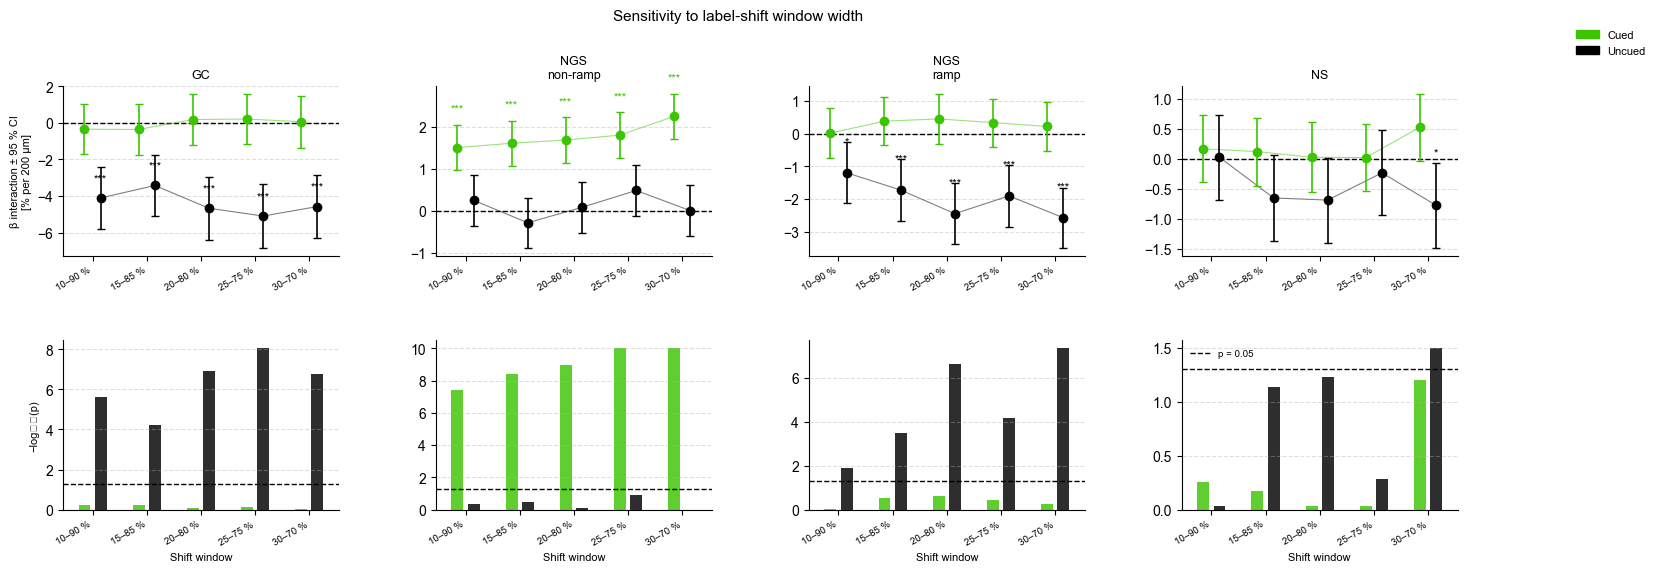

In [12]:

# ── Sensitivity figure: β and p across shift bounds ───────────────────────────
# 2-row × n_cell_types-col grid.
#   Row 0: interaction β ± 95 % CI for each shift bound (Cued / Uncued)
#   Row 1: −log₁₀(p) bar chart with p = 0.05 threshold line
# x-axis: five shift bounds; two offset series per panel (Cued / Uncued).

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

df_s = multi_bounds_df.copy()
df_s['-log10p'] = -np.log10(df_s['p'].clip(lower=1e-10))

bounds_order  = sorted(df_s['lo_frac'].unique())       # [0.10, 0.15, 0.20, 0.25, 0.30]
bound_xlabels = [_BOUND_LABEL[(lo, 1.0 - lo)] for lo in bounds_order]
bound_xpos    = {lo: i for i, lo in enumerate(bounds_order)}

x_offsets     = {'Cued': -0.15, 'Uncued': 0.15}
p05_line      = -np.log10(0.05)

n_ct = len(all_cell_labels)
n_bounds = len(bounds_order)
fig, axes = plt.subplots(2, n_ct, figsize=(max(3.0, 0.9 * n_bounds) * n_ct, 5.5),
                         gridspec_kw={'hspace': 0.50, 'wspace': 0.35})
fig.suptitle('Sensitivity to label-shift window width', fontsize=11, y=1.02)

for col_i, cell_label in enumerate(all_cell_labels):
    ax_b = axes[0, col_i]
    ax_p = axes[1, col_i]

    sub = df_s[df_s['Cell type'] == cell_label]

    for trial_label in ['Cued', 'Uncued']:
        color  = trial_colors[trial_label]
        x_off  = x_offsets[trial_label]
        sub_t  = sub[sub['Trial type'] == trial_label].sort_values('lo_frac')

        xs      = [bound_xpos[r] + x_off for r in sub_t['lo_frac']]
        betas   = sub_t['β'].values
        ci_errs = 1.96 * sub_t['se'].values        # symmetric ±1.96 SE
        log_ps  = sub_t['-log10p'].values
        sigs    = sub_t['sig'].values

        # ── β panel ─────────────────────────────────────────────────────
        ax_b.errorbar(xs, betas, yerr=ci_errs,
                      fmt='o', color=color, capsize=3, markersize=6,
                      linewidth=1.2, zorder=5)
        # connect the five points with a line to make trend legible
        ax_b.plot(xs, betas, color=color, linewidth=0.8, alpha=0.5, zorder=4)

        for x, b, s in zip(xs, betas, sigs):
            if s not in ('ns', '—', ''):
                ax_b.text(x, b + 0.8, s, ha='center', va='bottom',
                          fontsize=8, color=color)

        # ── p panel ─────────────────────────────────────────────────────
        bar_w = 0.22
        ax_p.bar(xs, log_ps, width=bar_w, color=color, alpha=0.82)

    # ── Styling: β panel ─────────────────────────────────────────────────
    ax_b.axhline(0, color='k', linestyle='--', linewidth=1)
    ax_b.set_xticks(list(bound_xpos.values()))
    ax_b.set_xticklabels(bound_xlabels, fontsize=7, rotation=30, ha='right')
    ax_b.set_xlim(-0.55, len(bounds_order) - 0.45)
    ax_b.set_title(cell_short.get(cell_label, cell_label), fontsize=9)
    if col_i == 0:
        ax_b.set_ylabel('β interaction ± 95 % CI\n[% per 200 µm]', fontsize=8)
    else:
        ax_b.set_ylabel('')
    ax_b.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=ax_b)

    # ── Styling: p panel ─────────────────────────────────────────────────
    ax_p.axhline(p05_line, color='k', linestyle='--', linewidth=1, label='p = 0.05')
    ax_p.set_xticks(list(bound_xpos.values()))
    ax_p.set_xticklabels(bound_xlabels, fontsize=7, rotation=30, ha='right')
    ax_p.set_xlim(-0.55, len(bounds_order) - 0.45)
    ax_p.set_xlabel('Shift window', fontsize=8)
    if col_i == 0:
        ax_p.set_ylabel('−log₁₀(p)', fontsize=8)
    else:
        ax_p.set_ylabel('')
    ax_p.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == n_ct - 1:
        ax_p.legend(fontsize=7, frameon=False)
    sns.despine(ax=ax_p)

# ── Legend ────────────────────────────────────────────────────────────────────
cued_patch   = mpatches.Patch(color=trial_colors['Cued'],   label='Cued')
uncued_patch = mpatches.Patch(color=trial_colors['Uncued'], label='Uncued')
fig.legend(handles=[cued_patch, uncued_patch], fontsize=8, frameon=False,
           loc='upper right', bbox_to_anchor=(1.01, 1.0))

plt.savefig('ml_interaction_shift_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Figure: ML-axis modulation of anchoring effect — real vs shuffle

The panel below re-plots the medial-lateral (SC_x) binned anchoring effect (Δ hit rate = anchored − non-anchored) for each cell type and trial type, showing **real data** (solid lines) against the canonical **20–80 % label-shift shuffle** (dashed hollow lines). The purpose is to visualise where along the ML axis the real and shuffled profiles diverge.

### Statistical test

For each cell-type × trial-type combination, a single linear mixed model tests whether the SC_x gradient in real data is significantly steeper than the shuffle null:

$$\delta \sim \mathrm{SC}_{x,\mathrm{scaled}} \times C(\mathrm{is\_real}) \;+\; (1 \mid \mathrm{mouse}) \;+\; VC(\mathrm{day}) \;+\; VC(\mathrm{cluster})$$

The key term is the **interaction** $\hat{\beta}_{\mathrm{SC}_x \times \mathrm{real}}$:

| Sign & significance | Interpretation |
|---|---|
| Positive, significant | Real ML gradient is steeper than the anatomical-bias null — SC_x position genuinely modulates the anchoring effect |
| Non-significant | The gradient cannot be distinguished from spatial sampling bias in the shuffle |

Each panel is annotated with this interaction coefficient (β ± 1.96 SE), the z-statistic, and the p-value. Significance stars are shown in the panel title when p < 0.05.

---

### Position estimation index (PEI): what does it measure?

**Δ hit rate** for a given trial type quantifies the **benefit of neural anchoring** for that condition:

$$\Delta\text{hit rate}_i = \text{hit rate}^{\text{anchored}}_i - \text{hit rate}^{\text{non-anchored}}_i$$

#### Why the cued/uncued contrast matters

The two trial types differ in which behavioural strategies are available:

- **Cued trials** — landmarks are visible throughout. Animals can succeed via **cue-based responding** (H1) *or* **position estimation** (H2). Even in the non-anchored state, H1 provides a viable fallback — the cue is present and no spatial representation is needed to respond to it. This *elevates the non-anchored baseline*, compressing Δ hit rate.
- **Uncued trials** — landmarks are absent. H1 is useless; the only path to success is **position estimation** (H2). Non-anchored animals have no fallback, so the gap between anchored and non-anchored is at its widest.

#### PEI as a strategy-selectivity contrast

PEI subtracts the cued anchoring benefit from the uncued anchoring benefit:

$$\text{PEI}_i = \Delta\text{hit rate}^{\text{Uncued}}_i - \Delta\text{hit rate}^{\text{Cued}}_i$$

This **partials out the general anchoring benefit** present in both conditions and isolates the *additional* benefit that only appears when position estimation is the sole available strategy. It is equivalent to asking: *does the anchoring benefit depend on whether landmarks are present?*

| Cell type | Δ HR Cued | Δ HR Uncued | PEI | Interpretation |
|---|---|---|---|---|
| Position-estimation cell | 5 % | 20 % | **+15 %** | Anchoring most useful when only H2 is available |
| General spatial cell | 10 % | 10 % | **0 %** | Anchoring benefit is landmark-independent |
| Cue-response cell | 15 % | 3 % | **−12 %** | Anchoring most useful when landmarks are present |

#### Why PEI is a well-motivated metric

1. **Built-in control for non-specific effects.** Any cell that makes anchored animals better at *everything* contributes equally to both Δ HR values, leaving PEI near zero. Only cells whose contribution is *conditionally necessary* — i.e., when landmarks are absent — yield a positive PEI.
2. **It is an interaction, not a main effect.** PEI is a Cell × Trial-type interaction contrast — the most specific question the cued/uncued design can answer about strategy selectivity.
3. **The null is well-defined.** A cue-response-specific cell gives negative PEI; a non-spatial cell gives PEI ≈ 0; only a position-estimation cell gives reliably positive PEI.

#### What the figure tests

**The key question asks:** does PEI vary systematically along the medial-lateral axis of MEC — and does that gradient exceed the label-shift shuffle null?

The same real-vs-shuffle interaction LMM is applied with PEI as the dependent variable. A significant positive gradient would indicate that medially-positioned cells are the principal locus through which position-estimation-based anchoring influences behaviour — consistent with the known medial bias of grid-cell spatial coding. A null result would suggest that position-estimation-dependent anchoring is distributed uniformly across the ML axis.

---

### Pairwise PEI comparisons across cell types

To directly compare the position estimation index (PEI = Δ HR<sup>Uncued</sup> − Δ HR<sup>Cued</sup>) between cell types, a pairwise LMM is fitted for each comparison:

$$\text{PEI} \sim \text{group} + (1 \mid \text{mouse})$$

where `group` is a binary indicator (0 = group A, 1 = group B) and mouse provides a random intercept to account for between-animal variability. The p-value for the `group` fixed effect is reported.

**Comparisons tested (annotated as brackets on the summary panel):**

| Comparison | Rationale |
|---|---|
| NGS ramp vs NGS non-ramp | Is the PEI effect specific to ramp-modulated NGS? |
| GC vs NGS (ramp + non-ramp) | Do grid cells show higher PEI than all NGS? |
| NGS (combined) vs NS | Do all NGS outperform the non-spatial baseline? |
| GC vs NS | Do grid cells outperform the non-spatial baseline? |

Brackets are stacked from innermost (shortest span) to outermost (longest span) on the PEI summary panel (row 2, column 1). Significance stars: \* p < 0.05, \*\* p < 0.01, \*\*\* p < 0.001; otherwise `n.s.`

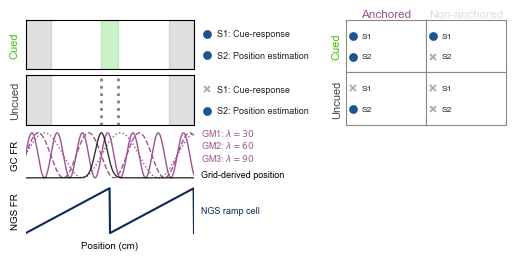

In [13]:
# ── Combined schematic: tracks (col 0) | strategy labels (col 1) | 2×2 grid (cols 2-3) ──
# Col 1 rows 2-3: axis-off panels listing which strategies are viable per trial type.
# 2×2 grid has zero gap between cells and is coloured with the summer colormap.
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

track_length = 200
half_track   = track_length / 2
x            = np.linspace(0, track_length, 400)
scm_color    = '#9d5391'
cmap         = plt.cm.summer

_anch_col    = '#9d5391'
_nonanch_col = '#e7d7e8'
_cued_col    = '#3bc500'
_uncued_col  = '#444444'
_avail_col   = '#1a5591'
_unavail_col = '#aaaaaa'

# hr: summer colormap value (0=dark green → 1=yellow); h1/h2: strategy availability
_cell_data = {
    (0, 0): dict(hr=0.90, label=r' ',     h1=True,  h2=True),
    (0, 1): dict(hr=0.55, label=r' ', h1=True,  h2=False),
    (1, 0): dict(hr=0.55, label=r' ', h1=False, h2=True),
    (1, 1): dict(hr=0.10, label=r' ', h1=False, h2=False),
}

# ── Layout ────────────────────────────────────────────────────────────────────
fig_scm = plt.figure(figsize=(6.2, 2.8))
gs_scm  = GridSpec(
    4, 4, figure=fig_scm,
    width_ratios=[2.8, 1.6, 1.1, 1.1],
    height_ratios=[0.7, 0.7, 0.7, 0.7],
    hspace=0.12, wspace=0.28,
)

ax_gc     = fig_scm.add_subplot(gs_scm[2, 0])
ax_ngs    = fig_scm.add_subplot(gs_scm[3, 0], sharex=ax_gc)
ax_cued   = fig_scm.add_subplot(gs_scm[0, 0], sharex=ax_gc)
ax_uncued = fig_scm.add_subplot(gs_scm[1, 0], sharex=ax_gc)

# Rows 0-1, cols 2-3: blank — holds "Neural anchoring state" super-label
ax_hdr = fig_scm.add_subplot(gs_scm[0:2, 2:])
ax_hdr.axis('off')
ax_hdr.set_xlim(0, 1); ax_hdr.set_ylim(0, 1)

# Col 1, rows 2-3: strategy-label axes (axis-off, markers + text inside)
ax_strat_cued   = fig_scm.add_subplot(gs_scm[0, 1])
ax_strat_uncued = fig_scm.add_subplot(gs_scm[1, 1])
for ax_s in [ax_strat_cued, ax_strat_uncued]:
    ax_s.axis('off')
    ax_s.set_xlim(0, 1); ax_s.set_ylim(0, 1)

# 2×2 grid via sub-GridSpec — zero gap between cells
gs_grid = GridSpecFromSubplotSpec(
    2, 2, subplot_spec=gs_scm[0:2, 2:4], wspace=0, hspace=0
)
ax_cells = {
    (0, 0): fig_scm.add_subplot(gs_grid[0, 0]),
    (0, 1): fig_scm.add_subplot(gs_grid[0, 1]),
    (1, 0): fig_scm.add_subplot(gs_grid[1, 0]),
    (1, 1): fig_scm.add_subplot(gs_grid[1, 1]),
}

# ── Row 0: GC firing rates ────────────────────────────────────────────────────
for p, ls in zip([30, 60, 90], ['-', '--', ':']):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    ax_gc.plot(x, y, color=scm_color, lw=1, ls=ls)
G = norm.pdf(x, 90, 7); G = G / G.max()
ax_gc.plot(x, G, color='black', lw=1, alpha=0.8)
ax_gc.set_xlim(0, 200); ax_gc.set_yticks([]); ax_gc.set_xticks([])
ax_gc.set_ylabel('GC FR', fontsize=7)
for sp in ['top', 'right', 'left', 'bottom']:
    ax_gc.spines[sp].set_visible(False)
ax_gc.text(1.04, 1.08, r'GM1: $\lambda=30$',     color=scm_color, fontsize=6.5, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.04, 0.82, r'GM2: $\lambda=60$',     color=scm_color, fontsize=6.5, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.04, 0.56, r'GM3: $\lambda=90$',     color=scm_color, fontsize=6.5, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.04, 0.20, r'Grid-derived position', color='black',   fontsize=6.5, transform=ax_gc.transAxes, va='top')

# ── Row 1: NGS ramp cell ──────────────────────────────────────────────────────
ramp = (x % half_track) / half_track
ax_ngs.plot(x, ramp, color=ngs_color_dark, lw=1.5)
ax_ngs.set_xlim(0, 200); ax_ngs.set_yticks([]); ax_ngs.set_xticks([])
ax_ngs.set_ylabel('NGS FR', fontsize=7)
for sp in ['top', 'right', 'left', 'bottom']:
    ax_ngs.spines[sp].set_visible(False)
ax_ngs.text(1.04, 0.50, 'NGS ramp cell', color=ngs_color_dark, fontsize=6.5,
            transform=ax_ngs.transAxes, va='center')
ax_ngs.set_xlabel('Position (cm)', fontsize=7)

# ── Row 2: Cued track ─────────────────────────────────────────────────────────
ax_cued.fill_betweenx([0, 1], 90, 110, color='limegreen', alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1],  0,  30, color='grey', alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
ax_cued.set_xlim(0, 200); ax_cued.set_ylim(0, 1)
ax_cued.set_yticks([]); ax_cued.set_xticks([])
ax_cued.set_ylabel('Cued', fontsize=8, color=_cued_col)

# ── Row 3: Uncued track ───────────────────────────────────────────────────────
ax_uncued.axvline(90,  color='grey', ls=':', lw=2)
ax_uncued.axvline(110, color='grey', ls=':', lw=2)
ax_uncued.fill_betweenx([0, 1],  0,  30, color='grey', alpha=0.25, zorder=0)
ax_uncued.fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
ax_uncued.set_xlim(0, 200); ax_uncued.set_ylim(0, 1); ax_uncued.set_yticks([])
ax_uncued.set_ylabel('Uncued', fontsize=8, color=_uncued_col)

# ── Strategy labels (col 1, rows 2-3) ─────────────────────────────────────────
_strat_rows = [
    (ax_strat_cued,   True,  True),   # Cued:   H1 ✓  H2 ✓
    (ax_strat_uncued, False, True),   # Uncued: H1 ✗  H2 ✓
]
for ax_s, h1, h2 in _strat_rows:
    m1, c1 = ('o', _avail_col)   if h1 else ('x', _unavail_col)
    m2, c2 = ('o', _avail_col)   if h2 else ('x', _unavail_col)
    ax_s.plot(-0.15, 0.72, m1, color=c1, markersize=5, mew=1.3, ls='none', clip_on=False)
    ax_s.text(-0.05, 0.72, 'S1: Cue-response',  ha='left', va='center', fontsize=6.5, color='#222222')
    ax_s.plot(-0.15, 0.28, m2, color=c2, markersize=5, mew=1.3, ls='none', clip_on=False)
    ax_s.text(-0.05, 0.28, 'S2: Position estimation', ha='left', va='center', fontsize=6.5, color='#222222')

# ── Column headers (aligned via set_title) ────────────────────────────────────
ax_cells[(0, 0)].set_title('Anchored',     fontsize=8.5, color=_anch_col, pad=2)
ax_cells[(0, 1)].set_title('Non-anchored', fontsize=8.5, color=_nonanch_col, pad=2)
ax_hdr.text(0.5, 0.21, 'Neural anchoring state', ha='center', va='center',
            fontsize=7.5, color='#555555', style='italic')

# ── Y-axis labels on the 2×2 grid ─────────────────────────────────────────────
ax_cells[(0, 0)].set_ylabel('Cued',   fontsize=8, color=_cued_col, labelpad=3)
ax_cells[(1, 0)].set_ylabel('Uncued', fontsize=8, color=_uncued_col, labelpad=3)


# ── 2×2 Grid cells: summer colormap background + H1/H2 indicators inside ──────
for (ri, ci), spec in _cell_data.items():
    ax_c = ax_cells[(ri, ci)]
    ax_c.set_facecolor('white')
    ax_c.set_xticks([]); ax_c.set_yticks([])
    for sp in ['top', 'right', 'left', 'bottom']:
        ax_c.spines[sp].set_color('#888888')
        ax_c.spines[sp].set_linewidth(0.8)

    # H1 — cue-response
    m1, c1 = ('o', _avail_col) if spec['h1'] else ('x', _unavail_col)
    ax_c.plot(0.09, 0.7, m1, color=c1, markersize=5, mew=1.3,
              transform=ax_c.transAxes, ls='none', clip_on=False)
    ax_c.text(0.20, 0.7, 'S1', ha='left', va='center',
              fontsize=6.0, color='#222222', transform=ax_c.transAxes)

    # H2 — position estimation
    m2, c2 = ('o', _avail_col) if spec['h2'] else ('x', _unavail_col)
    ax_c.plot(0.09, 0.3, m2, color=c2, markersize=5, mew=1.3,
              transform=ax_c.transAxes, ls='none', clip_on=False)
    ax_c.text(0.20, 0.3, 'S2', ha='left', va='center',
              fontsize=6.0, color='#222222', transform=ax_c.transAxes)

    # Hit-rate label
    ax_c.text(0.5, 0.16, spec['label'], ha='center', va='center',
              fontsize=7.0, fontweight='bold', style='italic',
              color='#333333', transform=ax_c.transAxes)

plt.tight_layout()
plt.savefig('task_anchoring_schematic_with_grid.pdf', dpi=300, bbox_inches='tight')
plt.show()


[0.0s] Building 'All cells' combined data...
[0.0s] All cells: 8927 neurons
[0.2s] Fitting LMM: All cells Cued...
[0.2s] Fitting LMM: All cells Uncued...
[0.3s] All cells LMMs done (eff_b=2.925, eff_nb=6.767)
[0.3s] Fitting LMM: Grid cells Cued...
[0.3s] Fitting LMM: Grid cells Uncued...
[0.3s] Grid cells: eff_b=1.665, eff_nb=9.124
[0.4s] Fitting LMM: NGS non-ramp Cued...
[0.4s] Fitting LMM: NGS non-ramp Uncued...
[0.4s] NGS non-ramp: eff_b=3.521, eff_nb=6.823
[0.5s] Fitting LMM: NGS ramp Cued...
[0.5s] Fitting LMM: NGS ramp Uncued...
[0.5s] NGS ramp: eff_b=2.638, eff_nb=6.406
[0.5s] Fitting LMM: NS cells Cued...
[0.6s] Fitting LMM: NS cells Uncued...
[0.6s] NS cells: eff_b=2.324, eff_nb=6.224
[0.6s] Precomputing shuffle LMMs...
[0.6s]   All cells: Cued shuffle LMM (8926 rows)...
[0.8s]   All cells: Uncued shuffle LMM...
[0.8s]   All cells: done
[0.8s]   Grid cells: Cued shuffle LMM (717 rows)...
[0.8s]   Grid cells: Uncued shuffle LMM...
[0.8s]   Grid cells: done
[0.8s]   NGS non-ramp

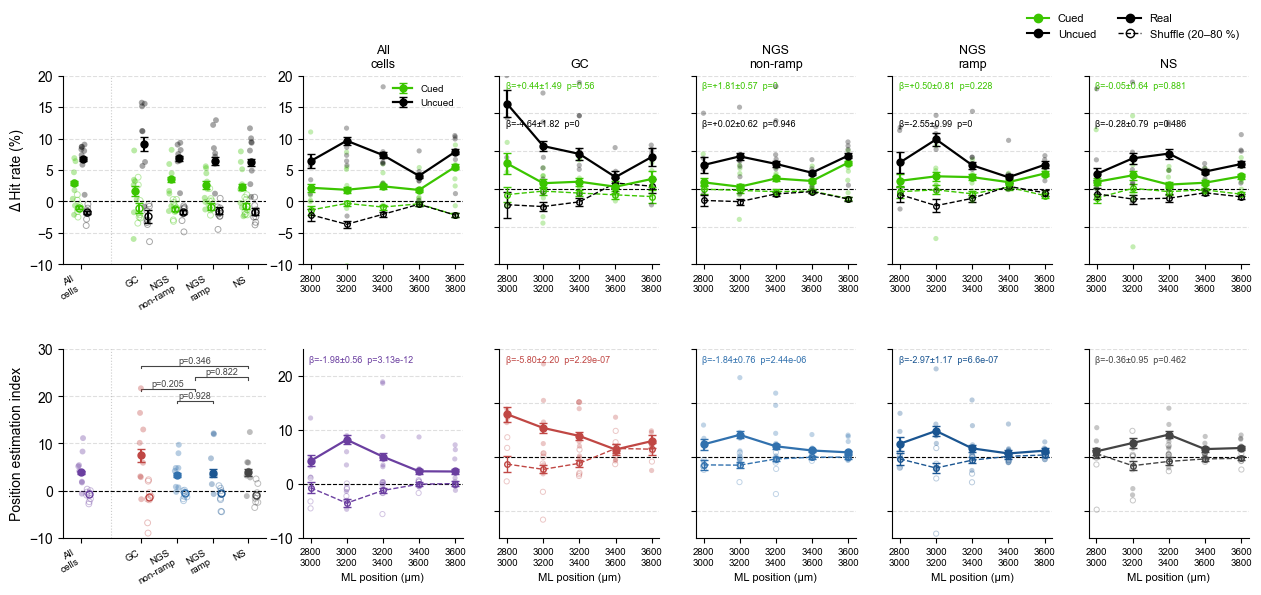

In [14]:
# ── Figure: ML-bin interaction figure (2 rows) ──────────────────────────────
# Row 0 : Effect-size col + ML-bin Cued+Uncued per cell type  [shared y per row]
# Row 1 : PI-sensitivity col + PI-sensitivity per bin per cell type  [shared y per row]

import time
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

_t0 = time.time()
def _elapsed(): return f"{time.time() - _t0:.1f}s"

# ── Helper functions ──────────────────────────────────────────────────────────
def _sem(x):
    x = x.dropna()
    return x.std() / np.sqrt(len(x)) if len(x) > 1 else np.nan

def build_records(df):
    """Melt cells_plot wide format → long format for LMM."""
    rows = []
    col_map = [
        ('b, label=1',  'pct_b_1',  'b'),
        ('b, label=0',  'pct_b_0',  'b'),
        ('nb, label=1', 'pct_nb_1', 'nb'),
        ('nb, label=0', 'pct_nb_0', 'nb'),
    ]
    for _, r in df.iterrows():
        for cond, col, tt in col_map:
            rows.append({
                'pct_hits':   r[col],
                'condition':  cond,
                'trial_type': tt,
                'mouse':      r['mouse'],
                'cluster_id': r.get('cluster_id', np.nan),
            })
    return pd.DataFrame(rows).dropna(subset=['pct_hits'])

def fit_lmm(df, name):
    """Fit pct_hits ~ anchored as LMM (random intercept by mouse).
    Returns (fit_result, effect_size_coef, se)."""
    import statsmodels.formula.api as smf
    df = df.copy().dropna(subset=['pct_hits'])
    df['anchored'] = df['condition'].str.contains('label=1').astype(float)
    if len(df) < 10:
        print(f"  {name}: too few rows ({len(df)}), skipping")
        return None, np.nan, np.nan
    try:
        md   = smf.mixedlm('pct_hits ~ anchored', df, groups=df['mouse'])
        mfit = md.fit(reml=False, method='lbfgs', disp=False)
        coef = mfit.fe_params['anchored']
        se   = mfit.bse_fe['anchored']
        return mfit, coef, se
    except Exception as e:
        print(f"  {name}: LMM failed ({e})")
        return None, np.nan, np.nan

def _fit_pi_comparison(cp_a, cp_b, name):
    """Compare PI (delta_nb - delta_b) between two cell groups via LMM.
    Model: sensitivity ~ group + (1|mouse) + (1|mouse:day).
    Returns (coef, p_value)."""
    import statsmodels.formula.api as smf
    df_a = cp_a[['mouse', 'day', 'delta_nb', 'delta_b']].copy()
    df_a['sensitivity'] = df_a['delta_nb'] - df_a['delta_b']
    df_a['group'] = 0
    df_b = cp_b[['mouse', 'day', 'delta_nb', 'delta_b']].copy()
    df_b['sensitivity'] = df_b['delta_nb'] - df_b['delta_b']
    df_b['group'] = 1
    df = pd.concat([df_a, df_b], ignore_index=True).dropna(subset=['sensitivity'])
    df['session'] = df['mouse'].astype(str) + '_' + df['day'].astype(str)
    if len(df) < 10:
        print(f"  {name}: too few rows ({len(df)}), skipping")
        return np.nan, np.nan
    try:
        md   = smf.mixedlm('sensitivity ~ group', df, groups=df['mouse'],
                            vc_formula={'session': '0 + C(session)'})
        mfit = md.fit(reml=False, method='lbfgs', disp=False)
        coef = mfit.fe_params['group']
        pval = mfit.pvalues['group']
        return coef, pval
    except Exception as e2:
        print(f"  {name}: LMM failed ({e2})")
        return np.nan, np.nan

# ── Ensure NS cells in stored_shuf ───────────────────────────────────────────
if 'NS cells' not in stored_shuf:
    _ns_shuf = shuffled_[shuffled_.cell_identity == 'NS']
    stored_shuf['NS cells'] = {
        'cells_plot': _build_plot_df(others_),
        'shuf_plot':  _build_plot_df(_ns_shuf) if len(_ns_shuf) else None,
    }
    print(f"Added NS cells: {len(others_)} cells, {len(_ns_shuf)} shuffle rows")

# ── Colours / labels ──────────────────────────────────────────────────────────
_all_color         = '#6b3fa0'
_all_color_light   = '#c4a8e0'
_ngs_ramp_color    = '#1a5591'
_ngs_nonramp_color = '#3171ae'
_ns_color          = '#444444'
cell_colors_fig = {
    'All cells':    _all_color,
    'Grid cells':   gc_color,
    'NGS ramp':     _ngs_ramp_color,
    'NGS non-ramp': _ngs_nonramp_color,
    'NS cells':     _ns_color,
}
cell_short_fig = {
    'All cells':    'All\ncells',
    'Grid cells':   'GC',
    'NGS ramp':     'NGS\nramp',
    'NGS non-ramp': 'NGS\nnon-ramp',
    'NS cells':     'NS',
}
_subtypes       = ['Grid cells', 'NGS non-ramp', 'NGS ramp', 'NS cells']
all_cell_labels = ['All cells'] + _subtypes
n_ct            = len(all_cell_labels)   # 5

# ── Build "All cells" combined data ──────────────────────────────────────────
print(f"[{_elapsed()}] Building 'All cells' combined data...")
_cp_parts, _sp_parts = [], []
for ct in _subtypes:
    cp = stored_shuf[ct]['cells_plot'].copy()
    cp['cluster_id'] = (cp['mouse'].astype(str) + '_' +
                        cp['day'].astype(str)   + '_' +
                        cp['cluster_id'].astype(str))
    _cp_parts.append(cp)
    sp = stored_shuf[ct]['shuf_plot']
    if sp is not None:
        sp2 = sp.copy()
        sp2['cluster_id'] = (sp2['mouse'].astype(str) + '_' +
                             sp2['day'].astype(str)   + '_' +
                             sp2['cluster_id'].astype(str))
        _sp_parts.append(sp2)

all_cp = pd.concat(_cp_parts, ignore_index=True)
all_sp = pd.concat(_sp_parts, ignore_index=True) if _sp_parts else None
print(f"[{_elapsed()}] All cells: {len(all_cp)} neurons")

# ── Fit LMMs for All cells ────────────────────────────────────────────────────
_order_rec = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
_df_all_r  = build_records(all_cp)
_df_all_r['condition'] = pd.Categorical(_df_all_r['condition'], categories=_order_rec, ordered=True)
print(f"[{_elapsed()}] Fitting LMM: All cells Cued...")
_, eff_b_all,  se_b_all  = fit_lmm(_df_all_r[_df_all_r['trial_type'] == 'b'],  'All cells Cued')
print(f"[{_elapsed()}] Fitting LMM: All cells Uncued...")
_, eff_nb_all, se_nb_all = fit_lmm(_df_all_r[_df_all_r['trial_type'] == 'nb'], 'All cells Uncued')
print(f"[{_elapsed()}] All cells LMMs done (eff_b={eff_b_all:.3f}, eff_nb={eff_nb_all:.3f})")

stored_shuf_local = dict(stored_shuf)
stored_shuf_local['All cells'] = dict(
    eff_b      = eff_b_all,  se_b      = se_b_all,
    eff_nb     = eff_nb_all, se_nb     = se_nb_all,
    cells_plot = all_cp,
    shuf_plot  = all_sp,
)

# ── Fit LMMs for each subtype ─────────────────────────────────────────────────
for ct in _subtypes:
    _cp_ct = stored_shuf[ct]['cells_plot']
    _df_ct = build_records(_cp_ct)
    _df_ct['condition'] = pd.Categorical(_df_ct['condition'], categories=_order_rec, ordered=True)
    print(f"[{_elapsed()}] Fitting LMM: {ct} Cued...")
    _, _eff_b_ct,  _se_b_ct  = fit_lmm(_df_ct[_df_ct['trial_type'] == 'b'],  f'{ct} Cued')
    print(f"[{_elapsed()}] Fitting LMM: {ct} Uncued...")
    _, _eff_nb_ct, _se_nb_ct = fit_lmm(_df_ct[_df_ct['trial_type'] == 'nb'], f'{ct} Uncued')
    stored_shuf_local[ct] = dict(
        eff_b      = _eff_b_ct,  se_b      = _se_b_ct,
        eff_nb     = _eff_nb_ct, se_nb     = _se_nb_ct,
        cells_plot = stored_shuf[ct]['cells_plot'],
        shuf_plot  = stored_shuf[ct]['shuf_plot'],
    )
    print(f"[{_elapsed()}] {ct}: eff_b={_eff_b_ct:.3f}, eff_nb={_eff_nb_ct:.3f}")

# ── Precompute shuffle LMM estimates per cell type ────────────────────────────
print(f"[{_elapsed()}] Precomputing shuffle LMMs...")
shuf_lmm = {}
for cell_label in all_cell_labels:
    d  = stored_shuf_local[cell_label]
    sp = d['shuf_plot']
    if sp is None or len(sp) == 0:
        shuf_lmm[cell_label] = {'Cued': (np.nan, np.nan), 'Uncued': (np.nan, np.nan)}
        print(f"[{_elapsed()}]   {cell_label}: no shuffle data, skipping")
        continue
    print(f"[{_elapsed()}]   {cell_label}: Cued shuffle LMM ({len(sp)} rows)...")
    df_s = build_records(sp)
    df_s['condition'] = pd.Categorical(df_s['condition'], categories=_order_rec, ordered=True)
    _, eff_b_s,  se_b_s  = fit_lmm(df_s[df_s['trial_type'] == 'b'],  f'{cell_label} shuf-b')
    print(f"[{_elapsed()}]   {cell_label}: Uncued shuffle LMM...")
    _, eff_nb_s, se_nb_s = fit_lmm(df_s[df_s['trial_type'] == 'nb'], f'{cell_label} shuf-nb')
    shuf_lmm[cell_label] = {'Cued': (eff_b_s, se_b_s), 'Uncued': (eff_nb_s, se_nb_s)}
    print(f"[{_elapsed()}]   {cell_label}: done")

# ── Precompute PI-sensitivity interaction test ────────────────────────────────
print(f"[{_elapsed()}] Precomputing PI-sensitivity interaction LMMs...")
pi_inter = {}
for cell_label in all_cell_labels:
    print(f"[{_elapsed()}]   {cell_label}: fit_scx_interaction_lmm...")
    d  = stored_shuf_local[cell_label]
    cp = d['cells_plot'].copy()
    sp = d['shuf_plot'].copy() if d['shuf_plot'] is not None else None
    cp['sensitivity'] = cp['delta_nb'] - cp['delta_b']
    if sp is not None:
        sp['sensitivity'] = sp['delta_nb'] - sp['delta_b']
    if sp is not None and len(sp) > 0:
        coef, z, p = fit_scx_interaction_lmm(cp, sp, f'{cell_label} PI-sens', 'sensitivity')
    else:
        coef, z, p = np.nan, np.nan, np.nan
    pi_inter[cell_label] = {'β': coef, 'z': z, 'p': p}
    print(f"[{_elapsed()}]   {cell_label}: β={coef:.3f}, p={p:.3g}")

# ── Pairwise PI comparisons across cell types (LMM) ──────────────────────────
print(f"[{_elapsed()}] Pairwise PI comparisons across cell types...")
_cp_gc      = stored_shuf_local['Grid cells']['cells_plot']
_cp_ngs_r   = stored_shuf_local['NGS ramp']['cells_plot']
_cp_ngs_nr  = stored_shuf_local['NGS non-ramp']['cells_plot']
_cp_ngs_all = pd.concat([_cp_ngs_r, _cp_ngs_nr], ignore_index=True)
_cp_ns      = stored_shuf_local['NS cells']['cells_plot']

_pi_comps = {}
for _cmp_name, _cpA, _cpB in [
    ('GC vs NGS',       _cp_gc,      _cp_ngs_all),
    ('NGS ramp vs nr',  _cp_ngs_r,   _cp_ngs_nr),
    ('GC vs NS',        _cp_gc,      _cp_ns),
    ('NGS vs NS',       _cp_ngs_all, _cp_ns),
]:
    _coef, _pval = _fit_pi_comparison(_cpA, _cpB, _cmp_name)
    _pi_comps[_cmp_name] = {'coef': _coef, 'p': _pval}
    print(f"[{_elapsed()}]   {_cmp_name}: Δ={_coef:.3f}, p={_pval:.3g}")



# ── x-positions for col-0 summary panels ─────────────────────────────────────
_gap      = 0.7
_x_eff    = {lbl: (0.0 if lbl == 'All cells' else i + _gap)
             for i, lbl in enumerate(all_cell_labels)}
_xlim_eff = (-0.5, max(_x_eff.values()) + 0.5)
_sep_x    = 0.85

# ── Figure layout: 2 rows × (1 + n_ct) cols ──────────────────────────────────
print(f"[{_elapsed()}] Building figure layout...")
fig = plt.figure(figsize=(2.8 + 2.5 * n_ct, 6.0))
gs  = fig.add_gridspec(
    2, 1 + n_ct,
    width_ratios=[2.8] + [2.2] * n_ct,
    height_ratios=[2.4, 2.4],
    hspace=0.45, wspace=0.22,
)

# ── Row 0, col 0 — effect size summary ───────────────────────────────────────
ax_eff = fig.add_subplot(gs[0, 0])

for cell_label in all_cell_labels:
    xb = _x_eff[cell_label]
    d  = stored_shuf_local[cell_label]
    cp = d['cells_plot']
    sp = d['shuf_plot']

    for trial_label, delta_col, eff_key, se_key, xr_off, xs_off in [
        ('Cued',   'delta_b',  'eff_b',  'se_b',  -0.18, -0.06),
        ('Uncued', 'delta_nb', 'eff_nb', 'se_nb', +0.06, +0.18),
    ]:
        color    = trial_colors[trial_label]
        xr, xs_p = xb + xr_off, xb + xs_off
        eff, se  = d[eff_key], d[se_key]
        if not np.isnan(eff):
            ax_eff.errorbar(xr, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, zorder=5)
            am = cp.groupby('mouse')[delta_col].mean().dropna()
            ax_eff.scatter(np.full(len(am), xr) + np.random.uniform(-0.05, 0.05, len(am)),
                           am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
        s_eff, s_se = shuf_lmm[cell_label].get(trial_label, (np.nan, np.nan))
        if not np.isnan(s_eff):
            ax_eff.errorbar(xs_p, s_eff, yerr=(s_se if not np.isnan(s_se) else None),
                            fmt='o', color=color, capsize=3, markersize=5,
                            mfc='none', mec=color, zorder=5)
            if sp is not None:
                am_s = sp.groupby('mouse')[delta_col].mean().dropna()
                ax_eff.scatter(
                    np.full(len(am_s), xs_p) + np.random.uniform(-0.05, 0.05, len(am_s)),
                    am_s, facecolors='none', edgecolors=color,
                    alpha=0.35, s=18, zorder=4, linewidths=0.7)

ax_eff.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_eff.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_eff.set_xticks([_x_eff[k] for k in all_cell_labels])
ax_eff.set_xticklabels([cell_short_fig.get(k, k) for k in all_cell_labels],
                       fontsize=7, rotation=30, ha='right')
ax_eff.set_xlim(*_xlim_eff)
ax_eff.set_ylabel('Δ Hit rate (%)', fontsize=10)
ax_eff.grid(axis='y', linestyle='--', alpha=0.4)
ax_eff.set_ylim(-10, 20)  # Set y-limits for first column
sns.despine(ax=ax_eff)

# ── Row 1, col 0 — Positional estimation index summary ─────────────────────────────────────
ax_pi = fig.add_subplot(gs[1, 0])

for cell_label in all_cell_labels:
    xb     = _x_eff[cell_label]
    d      = stored_shuf_local[cell_label]
    cp     = d['cells_plot']
    sp     = d['shuf_plot']
    color  = cell_colors_fig[cell_label]
    sens_r = d['eff_nb'] - d['eff_b']
    se_r   = (np.sqrt(d['se_nb']**2 + d['se_b']**2)
              if not (np.isnan(d['se_nb']) or np.isnan(d['se_b'])) else np.nan)
    if not np.isnan(sens_r):
        ax_pi.errorbar(xb, sens_r, yerr=(se_r if not np.isnan(se_r) else None),
                       fmt='o', color=color, capsize=3, markersize=5, zorder=5)
        am = cp.assign(sens=cp['delta_nb'] - cp['delta_b']).groupby('mouse')['sens'].mean().dropna()
        ax_pi.scatter(np.full(len(am), xb) + np.random.uniform(-0.07, 0.07, len(am)),
                      am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
    s_eff_b,  _ = shuf_lmm[cell_label].get('Cued',   (np.nan, np.nan))
    s_eff_nb, _ = shuf_lmm[cell_label].get('Uncued', (np.nan, np.nan))
    sens_s = s_eff_nb - s_eff_b
    if not np.isnan(sens_s):
        ax_pi.errorbar(xb + 0.22, sens_s, fmt='o', color=color, capsize=3,
                       markersize=5, mfc='none', mec=color, zorder=5)
        if sp is not None:
            am_s = sp.assign(sens=sp['delta_nb'] - sp['delta_b']).groupby('mouse')['sens'].mean().dropna()
            ax_pi.scatter(
                np.full(len(am_s), xb + 0.22) + np.random.uniform(-0.06, 0.06, len(am_s)),
                am_s, facecolors='none', edgecolors=color,
                alpha=0.35, s=18, zorder=4, linewidths=0.7)

ax_pi.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_pi.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_pi.set_xticks([_x_eff[k] for k in all_cell_labels])
ax_pi.set_xticklabels([cell_short_fig.get(k, k) for k in all_cell_labels],
                      fontsize=7, rotation=30, ha='right')
ax_pi.set_xlim(*_xlim_eff)
ax_pi.set_ylabel("Position estimation index", fontsize=10)
ax_pi.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=ax_pi)
# ── Pairwise bracket annotations on ax_pi ────────────────────────────────────
def _pval_stars(p):
    if np.isnan(p) or p >= 0.05: return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    return '*'

def _draw_bracket(ax, x1, x2, y, text, color='#444444', lw=0.8, fontsize=6.5):
    ylo, yhi = ax.get_ylim()
    tick_h = (yhi - ylo) * 0.012
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h],
            lw=lw, color=color, clip_on=False)
    ax.text((x1 + x2) / 2, y + tick_h * 0.3, text,
            ha='center', va='bottom', fontsize=fontsize, color=color, clip_on=False)

_x_gc      = _x_eff['Grid cells']
_x_ngs_r   = _x_eff['NGS ramp']
_x_ngs_nr  = _x_eff['NGS non-ramp']
_x_ngs_mid = (_x_ngs_r + _x_ngs_nr) / 2
_x_ns      = _x_eff['NS cells']

_bk_y0  = 19.0
_bk_dy  = 2.5
ax_pi.set_ylim(-10, _bk_y0 + 4 * _bk_dy + 1.0)

for _bk_i, (_cmp_name, _bk_x1, _bk_x2) in enumerate([
    ('NGS ramp vs nr', _x_ngs_nr,  _x_ngs_r),
    ('GC vs NGS',      _x_gc,      _x_ngs_mid),
    ('NGS vs NS',      _x_ngs_mid, _x_ns),
    ('GC vs NS',       _x_gc,      _x_ns),
]):
    _pval  = _pi_comps[_cmp_name]['p']
    _stars = _pval_stars(_pval)
    _txt   = f"p={_pval:.3g}" if not np.isnan(_pval) else 'n.s.'
    if _stars != 'n.s.':
        _txt = f"{_stars} ({_txt})"
    _draw_bracket(ax_pi, _bk_x1, _bk_x2, _bk_y0 + _bk_i * _bk_dy, _txt)

# ── Per-cell-type columns: rows 0 and 1 ──────────────────────────────────────
print(f"[{_elapsed()}] Plotting per-cell-type columns...")
for col_i, cell_label in enumerate(all_cell_labels):
    print(f"[{_elapsed()}]   Column {col_i+1}/{n_ct}: {cell_label}")
    ax_top = fig.add_subplot(gs[0, col_i + 1])
    ax_bot = fig.add_subplot(gs[1, col_i + 1])
 
    d          = stored_shuf_local[cell_label]
    cells_plot = d['cells_plot'].copy()
    shuf_plot  = d['shuf_plot'].copy() if d['shuf_plot'] is not None else None

    # ── Row 0: ML-bin Cued + Uncued ──────────────────────────────────────
    for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
        color = trial_colors[trial_label]
        means, sems, xs_c = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            bin_mask = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
            sub = cells_plot[bin_mask][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
            am = cells_plot[bin_mask].groupby('mouse')[delta_col].mean().dropna()
            ax_top.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                           am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
        ax_top.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                        capsize=3, linewidth=1.6, markersize=5, zorder=5, label=trial_label)
        if shuf_plot is not None:
            s_means, s_sems = [], []
            for (lo, hi), center in zip(sc_bins, sc_bin_centers):
                sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)][delta_col].dropna()
                s_means.append(sub.mean()); s_sems.append(_sem(sub))
            ax_top.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                            capsize=3, linewidth=1.0, markersize=4,
                            mfc='none', mec=color, zorder=3)

    if cell_label != 'All cells':
        for ann_i, trial_label in enumerate(['Cued', 'Uncued']):
            rm = results_df[(results_df['Cell type']  == cell_label) &
                            (results_df['Trial type'] == trial_label)]
            if len(rm):
                r      = rm.iloc[0]
                bv, zv = r['β (SC_x × real)'], r['z']
                pv     = r['p']
                se_v   = abs(bv / zv) if (not np.isnan(zv) and zv != 0) else np.nan
                color  = trial_colors[trial_label]
                annot  = (f"β={bv:+.2f}" +
                          (f"±{1.96*se_v:.2f}" if not np.isnan(se_v) else "") +
                          f"  p={pv:.3g}")
                ax_top.text(0.04, 0.97 - ann_i * 0.20, annot,
                            ha='left', va='top', fontsize=6.5, color=color,
                            transform=ax_top.transAxes)

    ax_top.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_top.set_xticks(sc_bin_centers)
    ax_top.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_top.set_title(cell_short_fig.get(cell_label, cell_label), fontsize=9)
    ax_top.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_top.legend(fontsize=7, frameon=False, loc='upper right')
        ax_top.set_ylim(-10, 20)  # First column y-lim for delta hit rate
        ax_top.set_yticklabels(ax_top.get_yticklabels())
    else:
        ax_top.set_ylim(-20, 30)  # Other columns y-lim for delta hit rate
        plt.setp(ax_top.get_yticklabels(), visible=False)
    sns.despine(ax=ax_top)

    # ── Row 1: Positional estimation index per bin ────────────────────────
    color = cell_colors_fig[cell_label]
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs_c = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        bin_mask = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
        sub = cells_plot[bin_mask]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
        am = cells_plot[bin_mask].groupby('mouse')['sensitivity'].mean().dropna()
        ax_bot.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                       am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
    ax_bot.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                    capsize=3, linewidth=1.6, markersize=5, zorder=5)

    if shuf_plot is not None:
        shuf_plot['sensitivity'] = shuf_plot['delta_nb'] - shuf_plot['delta_b']
        s_means, s_sems = [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            bm_s = (shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)
            sub  = shuf_plot[bm_s]['sensitivity'].dropna()
            s_means.append(sub.mean()); s_sems.append(_sem(sub))
            am_s = shuf_plot[bm_s].groupby('mouse')['sensitivity'].mean().dropna()
            ax_bot.scatter(np.full(len(am_s), center) + np.random.uniform(-2, 2, len(am_s)),
                           am_s, facecolors='none', edgecolors=color,
                           alpha=0.30, s=14, zorder=3, linewidths=0.7)
        ax_bot.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                        capsize=3, linewidth=1.0, markersize=4,
                        mfc='none', mec=color, zorder=3)

    pi_res = pi_inter.get(cell_label, {})
    pi_bv  = pi_res.get('β', np.nan)
    pi_zv  = pi_res.get('z', np.nan)
    pi_pv  = pi_res.get('p', np.nan)
    if not np.isnan(pi_bv):
        pi_se  = abs(pi_bv / pi_zv) if (not np.isnan(pi_zv) and pi_zv != 0) else np.nan
        pi_ann = (f"β={pi_bv:+.2f}" +
                  (f"±{1.96*pi_se:.2f}" if not np.isnan(pi_se) else "") +
                  f"  p={pi_pv:.3g}")
        ax_bot.text(0.04, 0.97, pi_ann, ha='left', va='top', fontsize=6.5,
                    color=color, transform=ax_bot.transAxes)

    ax_bot.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_bot.set_xticks(sc_bin_centers)
    ax_bot.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bot.set_xlabel('ML position (µm)', fontsize=8)
    ax_bot.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_bot.set_ylim(-10, 25)  # First column y-lim for position estimation index
        ax_bot.set_yticklabels(ax_bot.get_yticklabels())
    else:
        ax_bot.set_ylim(-30, 40)  # Other columns y-lim for position estimation index
        plt.setp(ax_bot.get_yticklabels(), visible=False)
    sns.despine(ax=ax_bot)

# ── Legend ────────────────────────────────────────────────────────────────────────────
print(f"[{_elapsed()}] Adding legend and saving...")
cued_line   = mlines.Line2D([], [], color=trial_colors['Cued'],   marker='o',
                             linewidth=1.5, label='Cued')
uncued_line = mlines.Line2D([], [], color=trial_colors['Uncued'], marker='o',
                             linewidth=1.5, label='Uncued')
real_line   = mlines.Line2D([], [], color='k', marker='o',
                             linewidth=1.5, label='Real')
shuf_line   = mlines.Line2D([], [], color='k', marker='o', linestyle='--',
                             linewidth=1.0, mfc='none', label='Shuffle (20–80 %)')
fig.legend(handles=[cued_line, uncued_line, real_line, shuf_line],
           fontsize=8, frameon=False, loc='upper right',
           bbox_to_anchor=(0.9, 1.0), ncol=2)
plt.savefig('ml_interaction_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()

[0.0s] Building groups (ENT_FILTER=True, RUN_TESTS=True)...
[0.1s]   All cells: 7386 neurons
[0.1s]   Grid cells: 628 neurons
[0.1s]   NGS: 5182 neurons
[0.4s] LMM All cells Cued...
[0.5s] LMM All cells Uncued...
[0.6s]   All cells: eff_b=3.084, eff_nb=6.636
[0.6s] LMM Grid cells Cued...
[0.6s] LMM Grid cells Uncued...
[0.6s]   Grid cells: eff_b=1.813, eff_nb=8.768
[0.9s] LMM NGS Cued...
[0.9s] LMM NGS Uncued...
[0.9s]   NGS: eff_b=3.409, eff_nb=6.495
[1.2s] Shuffle LMM All cells...
[1.3s] Shuffle LMM Grid cells...
[1.5s] Shuffle LMM NGS...
[1.6s]   All cells: fit_scx_interaction_lmm...
[448.2s]   All cells: β=-3.662, p=8.55e-18
[448.2s]   Grid cells: fit_scx_interaction_lmm...
[448.4s]   Grid cells: β=-5.900, p=1.45e-05
[448.4s]   NGS: fit_scx_interaction_lmm...
[478.3s]   NGS: β=-3.562, p=5.45e-13
[478.3s] GC vs NGS PI comparison...
[478.3s] GC vs NGS: Δ=-0.963, p=0.353
[478.3s] Valid bins: 4/5 (3100–3700 µm)
[478.3s] Building figure...
[478.4s] Plotting per-cell-type columns...
[478

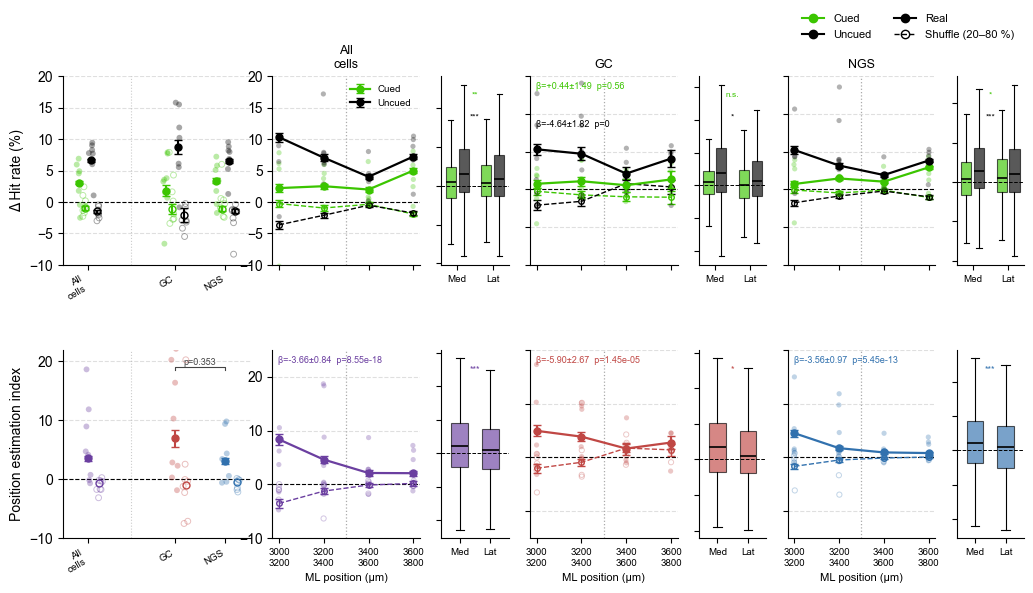

In [17]:
# ── Figure: ML-bin interaction (2 rows × 7 cols) ──────────────────────────────
# Row 0 : Effect-size summary | (ML-bin Δhit   + Med/Lat box) × [All, GC, NGS]
# Row 1 : PI summary          | (ML-bin PI      + Med/Lat box) × [All, GC, NGS]

import time
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# FLAGS — edit before running
RUN_TESTS    = True    # False → skip all LMMs; all statistical values become NaN
ENT_FILTER   = True    # True  → restrict to brain_region containing 'ENTm' (MEC only)
MEDLAT_SPLIT = 3400    # SC_x threshold (µm): < this = Medial, ≥ this = Lateral
# ══════════════════════════════════════════════════════════════════════════════

_t0 = time.time()
def _elapsed(): return f"{time.time() - _t0:.1f}s"

# ── Helpers ───────────────────────────────────────────────────────────────────
def _sem(x):
    x = x.dropna()
    return x.std() / np.sqrt(len(x)) if len(x) > 1 else np.nan

def _safe_concat(lst):
    valid = [x for x in lst if x is not None and len(x) > 0]
    return pd.concat(valid, ignore_index=True) if valid else None

def _ent_filter(df):
    if df is None: return None
    if ENT_FILTER and 'brain_region' in df.columns:
        return df[df['brain_region'].str.contains('ENTm', na=False)].copy()
    return df.copy()

def build_records(df):
    rows = []
    for _, r in df.iterrows():
        for cond, col, tt in [('b, label=1','pct_b_1','b'), ('b, label=0','pct_b_0','b'),
                               ('nb, label=1','pct_nb_1','nb'), ('nb, label=0','pct_nb_0','nb')]:
            rows.append({'pct_hits': r[col], 'condition': cond, 'trial_type': tt,
                         'mouse': r['mouse'], 'cluster_id': r.get('cluster_id', np.nan)})
    return pd.DataFrame(rows).dropna(subset=['pct_hits'])

def fit_lmm(df, name):
    import statsmodels.formula.api as smf
    df = df.copy().dropna(subset=['pct_hits'])
    df['anchored'] = df['condition'].str.contains('label=1').astype(float)
    if len(df) < 10:
        print(f"  {name}: too few rows ({len(df)}), skipping"); return None, np.nan, np.nan
    try:
        mfit = smf.mixedlm('pct_hits ~ anchored', df, groups=df['mouse']).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit, mfit.fe_params['anchored'], mfit.bse_fe['anchored']
    except Exception as e:
        print(f"  {name}: LMM failed ({e})"); return None, np.nan, np.nan

def _fit_medlat_lmm(cells_plot, value_col, name=''):
    """LMM: value_col ~ lateral (0=med, 1=lat), grouped by mouse."""
    import statsmodels.formula.api as smf
    df = cells_plot[['mouse', value_col, 'SC_x']].copy().dropna(
        subset=[value_col, 'mouse', 'SC_x'])
    df['lateral'] = (df['SC_x'] >= MEDLAT_SPLIT).astype(float)
    if len(df) < 10 or df['mouse'].nunique() < 2:
        return np.nan
    try:
        mfit = smf.mixedlm(f'{value_col} ~ lateral', df, groups=df['mouse']).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit.pvalues['lateral']
    except Exception as e:
        print(f"  medlat LMM {name}: {e}"); return np.nan

def _fit_pi_comparison(cp_a, cp_b, name):
    import statsmodels.formula.api as smf
    df_a = cp_a[['mouse','day','delta_nb','delta_b']].copy()
    df_a['sensitivity'] = df_a['delta_nb'] - df_a['delta_b'];  df_a['group'] = 0
    df_b = cp_b[['mouse','day','delta_nb','delta_b']].copy()
    df_b['sensitivity'] = df_b['delta_nb'] - df_b['delta_b'];  df_b['group'] = 1
    df = pd.concat([df_a, df_b], ignore_index=True).dropna(subset=['sensitivity'])
    df['session'] = df['mouse'].astype(str) + '_' + df['day'].astype(str)
    if len(df) < 10: return np.nan, np.nan
    try:
        mfit = smf.mixedlm('sensitivity ~ group', df, groups=df['mouse'],
                            vc_formula={'session': '0 + C(session)'}).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit.fe_params['group'], mfit.pvalues['group']
    except Exception as e:
        print(f"  {name}: {e}"); return np.nan, np.nan

def _pval_stars(p):
    if np.isnan(p) or p >= 0.05: return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    return '*'

def _pval_str(p):
    s = _pval_stars(p)
    txt = f"p={p:.3g}" if not np.isnan(p) else 'n.s.'
    return f"{s} ({txt})" if s != 'n.s.' else txt

def _draw_bracket(ax, x1, x2, y, text, color='#444444', lw=0.8, fontsize=6.5):
    ylo, yhi = ax.get_ylim()
    tick_h = (yhi - ylo) * 0.012
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h], lw=lw, color=color, clip_on=False)
    ax.text((x1+x2)/2, y + tick_h*0.3, text, ha='center', va='bottom',
            fontsize=fontsize, color=color, clip_on=False)

# ── Ensure NS cells ───────────────────────────────────────────────────────────
if 'NS cells' not in stored_shuf:
    _ns_shuf = shuffled_[shuffled_.cell_identity == 'NS']
    stored_shuf['NS cells'] = {
        'cells_plot': _build_plot_df(others_),
        'shuf_plot':  _build_plot_df(_ns_shuf) if len(_ns_shuf) else None,
    }
    print(f"Added NS cells: {len(others_)} cells")

# ── Colors ────────────────────────────────────────────────────────────────────
cell_colors_fig = {'All cells': '#6b3fa0', 'Grid cells': gc_color, 'NGS': '#3171ae'}
cell_short_fig  = {'All cells': 'All\ncells', 'Grid cells': 'GC', 'NGS': 'NGS'}
display_labels  = ['All cells', 'Grid cells', 'NGS']
n_ct            = len(display_labels)

# ── Build ENTm-filtered groups ────────────────────────────────────────────────
print(f"[{_elapsed()}] Building groups (ENT_FILTER={ENT_FILTER}, RUN_TESTS={RUN_TESTS})...")
_src = {}
for ct in ['Grid cells', 'NGS ramp', 'NGS non-ramp', 'NS cells']:
    d = stored_shuf.get(ct, {})
    _src[ct] = {'cells_plot': _ent_filter(d.get('cells_plot')),
                'shuf_plot':  _ent_filter(d.get('shuf_plot'))}

_raw = {}
_raw['Grid cells'] = _src['Grid cells']
_raw['NGS'] = {
    'cells_plot': _safe_concat([_src['NGS ramp']['cells_plot'], _src['NGS non-ramp']['cells_plot']]),
    'shuf_plot':  _safe_concat([_src['NGS ramp']['shuf_plot'],  _src['NGS non-ramp']['shuf_plot']]),
}
_acp, _asp = [], []
for ct in ['Grid cells', 'NGS ramp', 'NGS non-ramp', 'NS cells']:
    for src_key, lst in [('cells_plot', _acp), ('shuf_plot', _asp)]:
        df = _src[ct][src_key]
        if df is not None and len(df):
            df2 = df.copy()
            df2['cluster_id'] = (df2['mouse'].astype(str) + '_' + df2['day'].astype(str) +
                                 '_' + df2['cluster_id'].astype(str))
            lst.append(df2)
_raw['All cells'] = {'cells_plot': _safe_concat(_acp), 'shuf_plot': _safe_concat(_asp)}

for lbl in display_labels:
    n = len(_raw[lbl]['cells_plot']) if _raw[lbl]['cells_plot'] is not None else 0
    print(f"[{_elapsed()}]   {lbl}: {n} neurons")

# ── LMMs (or NaN if RUN_TESTS=False) ─────────────────────────────────────────
_order_rec = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
stored_disp = {}
for cell_label in display_labels:
    cp = _raw[cell_label]['cells_plot']
    sp = _raw[cell_label]['shuf_plot']
    if RUN_TESTS and cp is not None and len(cp) >= 10:
        _df = build_records(cp)
        _df['condition'] = pd.Categorical(_df['condition'], categories=_order_rec, ordered=True)
        print(f"[{_elapsed()}] LMM {cell_label} Cued...")
        _, eff_b,  se_b  = fit_lmm(_df[_df['trial_type'] == 'b'],  f'{cell_label} Cued')
        print(f"[{_elapsed()}] LMM {cell_label} Uncued...")
        _, eff_nb, se_nb = fit_lmm(_df[_df['trial_type'] == 'nb'], f'{cell_label} Uncued')
    else:
        eff_b = se_b = eff_nb = se_nb = np.nan
    stored_disp[cell_label] = dict(eff_b=eff_b, se_b=se_b, eff_nb=eff_nb, se_nb=se_nb,
                                   cells_plot=cp, shuf_plot=sp)
    print(f"[{_elapsed()}]   {cell_label}: eff_b={eff_b:.3f}, eff_nb={eff_nb:.3f}")

# ── Shuffle LMMs ─────────────────────────────────────────────────────────────
shuf_lmm = {}
for cell_label in display_labels:
    sp = stored_disp[cell_label]['shuf_plot']
    if RUN_TESTS and sp is not None and len(sp) >= 10:
        df_s = build_records(sp)
        df_s['condition'] = pd.Categorical(df_s['condition'], categories=_order_rec, ordered=True)
        print(f"[{_elapsed()}] Shuffle LMM {cell_label}...")
        _, eff_b_s,  se_b_s  = fit_lmm(df_s[df_s['trial_type'] == 'b'],  f'{cell_label} shuf-b')
        _, eff_nb_s, se_nb_s = fit_lmm(df_s[df_s['trial_type'] == 'nb'], f'{cell_label} shuf-nb')
        shuf_lmm[cell_label] = {'Cued': (eff_b_s, se_b_s), 'Uncued': (eff_nb_s, se_nb_s)}
    else:
        shuf_lmm[cell_label] = {'Cued': (np.nan, np.nan), 'Uncued': (np.nan, np.nan)}

# ── PI-sensitivity interaction LMMs ──────────────────────────────────────────
pi_inter = {}
for cell_label in display_labels:
    if RUN_TESTS:
        d  = stored_disp[cell_label]
        cp = d['cells_plot'].copy() if d['cells_plot'] is not None else None
        sp = d['shuf_plot'].copy()  if d['shuf_plot']  is not None else None
        if cp is not None: cp['sensitivity'] = cp['delta_nb'] - cp['delta_b']
        if sp is not None: sp['sensitivity'] = sp['delta_nb'] - sp['delta_b']
        if cp is not None and sp is not None and len(sp) > 0:
            print(f"[{_elapsed()}]   {cell_label}: fit_scx_interaction_lmm...")
            coef, z, p = fit_scx_interaction_lmm(cp, sp, f'{cell_label} PI-sens', 'sensitivity')
        else:
            coef, z, p = np.nan, np.nan, np.nan
    else:
        coef, z, p = np.nan, np.nan, np.nan
    pi_inter[cell_label] = {'β': coef, 'z': z, 'p': p}
    print(f"[{_elapsed()}]   {cell_label}: β={coef:.3f}, p={p:.3g}")

# ── Pairwise PI: GC vs NGS ────────────────────────────────────────────────────
if RUN_TESTS:
    print(f"[{_elapsed()}] GC vs NGS PI comparison...")
    _gc_ngs_coef, _gc_ngs_p = _fit_pi_comparison(
        stored_disp['Grid cells']['cells_plot'],
        stored_disp['NGS']['cells_plot'], 'GC vs NGS')
else:
    _gc_ngs_coef, _gc_ngs_p = np.nan, np.nan
_pi_comps = {'GC vs NGS': {'coef': _gc_ngs_coef, 'p': _gc_ngs_p}}
print(f"[{_elapsed()}] GC vs NGS: Δ={_gc_ngs_coef:.3f}, p={_gc_ngs_p:.3g}")

# ── x-positions for summary col ───────────────────────────────────────────────
_gap      = 0.7
_x_eff    = {lbl: (0.0 if lbl == 'All cells' else i + _gap) for i, lbl in enumerate(display_labels)}
_xlim_eff = (-0.5, max(_x_eff.values()) + 0.5)
_sep_x    = 0.85

# ── Valid bins — skip bins with no data across all groups ─────────────────────
_valid_mask = []
for lo, hi in sc_bins:
    _has = any(
        stored_disp[lbl]['cells_plot'] is not None and
        int(((stored_disp[lbl]['cells_plot']['SC_x'] >= lo) &
             (stored_disp[lbl]['cells_plot']['SC_x'] <  hi)).sum()) > 0
        for lbl in display_labels
    )
    _valid_mask.append(_has)
_valid_bins        = [b for b, v in zip(sc_bins,        _valid_mask) if v]
_valid_bin_centers = [c for c, v in zip(sc_bin_centers, _valid_mask) if v]
_valid_bin_labels  = [l for l, v in zip(sc_bin_labels,  _valid_mask) if v]
_xpad_line         = (max(_valid_bin_centers) - min(_valid_bin_centers)) * 0.05
_xlim_line         = (min(_valid_bin_centers) - _xpad_line, max(_valid_bin_centers) + _xpad_line)
print(f"[{_elapsed()}] Valid bins: {len(_valid_bins)}/{len(sc_bins)} "
      f"({_valid_bin_centers[0]}–{_valid_bin_centers[-1]} µm)")

# ── Boxplot helpers ───────────────────────────────────────────────────────────
def _medlat_boxplot_row0(ax, cells_plot, p_b=np.nan, p_nb=np.nan):
    """Δ hit rate boxes split at MEDLAT_SPLIT; p values from LMM."""
    med = cells_plot[cells_plot['SC_x'] <  MEDLAT_SPLIT]
    lat = cells_plot[cells_plot['SC_x'] >= MEDLAT_SPLIT]
    data      = [med['delta_b'].dropna(), med['delta_nb'].dropna(),
                 lat['delta_b'].dropna(), lat['delta_nb'].dropna()]
    positions = [0.0, 0.38, 1.05, 1.43]
    bp_colors = [trial_colors['Cued'], trial_colors['Uncued'],
                 trial_colors['Cued'], trial_colors['Uncued']]
    bp = ax.boxplot(data, positions=positions, widths=0.30, patch_artist=True,
                    showfliers=False, medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    for patch, c in zip(bp['boxes'], bp_colors):
        patch.set_facecolor(c);  patch.set_alpha(0.65)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)
    ax.set_xticks([0.19, 1.24]);  ax.set_xticklabels(['Med', 'Lat'], fontsize=7)
    ax.set_xlim(-0.28, 1.71);  ax.tick_params(labelleft=False)
    sns.despine(ax=ax)
    for p, y_frac, trial_lbl in [(p_b, 0.92, 'Cued'), (p_nb, 0.80, 'Uncued')]:
        if not np.isnan(p):
            ax.text(0.5, y_frac, _pval_stars(p), ha='center', va='top', fontsize=6,
                    color=trial_colors[trial_lbl], transform=ax.transAxes)

def _medlat_boxplot_row1(ax, cells_plot, color, p=np.nan):
    """PI (sensitivity) boxes split at MEDLAT_SPLIT; p value from LMM."""
    cp = cells_plot.copy()
    cp['sensitivity'] = cp['delta_nb'] - cp['delta_b']
    med = cp[cp['SC_x'] <  MEDLAT_SPLIT]['sensitivity'].dropna()
    lat = cp[cp['SC_x'] >= MEDLAT_SPLIT]['sensitivity'].dropna()
    bp = ax.boxplot([med, lat], positions=[0, 1], widths=0.55, patch_artist=True,
                    showfliers=False, medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    for patch in bp['boxes']:
        patch.set_facecolor(color);  patch.set_alpha(0.65)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)
    ax.set_xticks([0, 1]);  ax.set_xticklabels(['Med', 'Lat'], fontsize=7)
    ax.set_xlim(-0.6, 1.6);  ax.tick_params(labelleft=False)
    sns.despine(ax=ax)
    if not np.isnan(p):
        ax.text(0.5, 0.92, _pval_stars(p), ha='center', va='top', fontsize=6.5,
                color=color, transform=ax.transAxes)

# ── Figure layout: 2 rows × 7 cols ───────────────────────────────────────────
print(f"[{_elapsed()}] Building figure...")
_lw, _bw = 2.2, 1.0
fig = plt.figure(figsize=(2.8 + (_lw + _bw) * n_ct, 6.0))
gs  = fig.add_gridspec(
    2, 1 + 2 * n_ct,
    width_ratios=[2.8] + [w for _ in range(n_ct) for w in [_lw, _bw]],
    height_ratios=[2.4, 2.4],
    hspace=0.45, wspace=0.18,
)

# ── Row 0, col 0 — effect size summary ───────────────────────────────────────
ax_eff = fig.add_subplot(gs[0, 0])
for cell_label in display_labels:
    xb = _x_eff[cell_label];  d = stored_disp[cell_label]
    cp = d['cells_plot'];       sp = d['shuf_plot']
    for trial_label, delta_col, eff_key, se_key, xr_off, xs_off in [
        ('Cued',   'delta_b',  'eff_b',  'se_b',  -0.18, -0.06),
        ('Uncued', 'delta_nb', 'eff_nb', 'se_nb', +0.06, +0.18),
    ]:
        color    = trial_colors[trial_label]
        xr, xs_p = xb + xr_off, xb + xs_off
        eff, se  = d[eff_key], d[se_key]
        if not np.isnan(eff):
            ax_eff.errorbar(xr, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, zorder=5)
            am = cp.groupby('mouse')[delta_col].mean().dropna()
            ax_eff.scatter(np.full(len(am), xr) + np.random.uniform(-0.05, 0.05, len(am)),
                           am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
        s_eff, s_se = shuf_lmm[cell_label].get(trial_label, (np.nan, np.nan))
        if not np.isnan(s_eff):
            ax_eff.errorbar(xs_p, s_eff, yerr=(s_se if not np.isnan(s_se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, mfc='none', mec=color, zorder=5)
            if sp is not None:
                am_s = sp.groupby('mouse')[delta_col].mean().dropna()
                ax_eff.scatter(np.full(len(am_s), xs_p) + np.random.uniform(-0.05, 0.05, len(am_s)),
                               am_s, facecolors='none', edgecolors=color, alpha=0.35, s=18, zorder=4, linewidths=0.7)
ax_eff.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_eff.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_eff.set_xticks([_x_eff[k] for k in display_labels])
ax_eff.set_xticklabels([cell_short_fig[k] for k in display_labels], fontsize=7, rotation=30, ha='right')
ax_eff.set_xlim(*_xlim_eff);  ax_eff.set_ylabel('Δ Hit rate (%)', fontsize=10)
ax_eff.grid(axis='y', linestyle='--', alpha=0.4);  ax_eff.set_ylim(-10, 20)
sns.despine(ax=ax_eff)

# ── Row 1, col 0 — PI summary ────────────────────────────────────────────────
ax_pi = fig.add_subplot(gs[1, 0])
for cell_label in display_labels:
    xb    = _x_eff[cell_label];  d = stored_disp[cell_label]
    cp    = d['cells_plot'];      sp = d['shuf_plot']
    color = cell_colors_fig[cell_label]
    sens_r = d['eff_nb'] - d['eff_b']
    se_r   = (np.sqrt(d['se_nb']**2 + d['se_b']**2)
              if not (np.isnan(d['se_nb']) or np.isnan(d['se_b'])) else np.nan)
    if not np.isnan(sens_r):
        ax_pi.errorbar(xb, sens_r, yerr=(se_r if not np.isnan(se_r) else None),
                       fmt='o', color=color, capsize=3, markersize=5, zorder=5)
        am = cp.assign(sens=cp['delta_nb'] - cp['delta_b']).groupby('mouse')['sens'].mean().dropna()
        ax_pi.scatter(np.full(len(am), xb) + np.random.uniform(-0.07, 0.07, len(am)),
                      am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
    s_eff_b,  _ = shuf_lmm[cell_label].get('Cued',   (np.nan, np.nan))
    s_eff_nb, _ = shuf_lmm[cell_label].get('Uncued', (np.nan, np.nan))
    sens_s = s_eff_nb - s_eff_b
    if not np.isnan(sens_s):
        ax_pi.errorbar(xb + 0.22, sens_s, fmt='o', color=color, capsize=3,
                       markersize=5, mfc='none', mec=color, zorder=5)
        if sp is not None:
            am_s = sp.assign(sens=sp['delta_nb'] - sp['delta_b']).groupby('mouse')['sens'].mean().dropna()
            ax_pi.scatter(np.full(len(am_s), xb + 0.22) + np.random.uniform(-0.06, 0.06, len(am_s)),
                          am_s, facecolors='none', edgecolors=color, alpha=0.35, s=18, zorder=4, linewidths=0.7)
ax_pi.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_pi.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_pi.set_xticks([_x_eff[k] for k in display_labels])
ax_pi.set_xticklabels([cell_short_fig[k] for k in display_labels], fontsize=7, rotation=30, ha='right')
ax_pi.set_xlim(*_xlim_eff);  ax_pi.set_ylabel('Position estimation index', fontsize=10)
ax_pi.grid(axis='y', linestyle='--', alpha=0.4)
_bk_y0 = 19.0;  ax_pi.set_ylim(-10, _bk_y0 + 3.0)
_draw_bracket(ax_pi, _x_eff['Grid cells'], _x_eff['NGS'], _bk_y0, _pval_str(_pi_comps['GC vs NGS']['p']))
sns.despine(ax=ax_pi)

# ── Per-cell-type columns (cols 1–6) ─────────────────────────────────────────
print(f"[{_elapsed()}] Plotting per-cell-type columns...")
for col_i, cell_label in enumerate(display_labels):
    print(f"[{_elapsed()}]   {cell_label} ({col_i+1}/{n_ct})...")
    col_line = 1 + 2 * col_i;  col_box = 2 + 2 * col_i

    ax_top     = fig.add_subplot(gs[0, col_line])
    ax_top_box = fig.add_subplot(gs[0, col_box])
    ax_bot     = fig.add_subplot(gs[1, col_line], sharex=ax_top)   # ← shared x-axis
    ax_bot_box = fig.add_subplot(gs[1, col_box])

    d          = stored_disp[cell_label]
    cells_plot = d['cells_plot'].copy()
    shuf_plot  = d['shuf_plot'].copy() if d['shuf_plot'] is not None else None
    color      = cell_colors_fig[cell_label]

    # ── Med/Lat LMMs for boxplots ─────────────────────────────────────────
    if RUN_TESTS and cells_plot is not None and 'SC_x' in cells_plot.columns:
        p_b_ml  = _fit_medlat_lmm(cells_plot, 'delta_b',  f'{cell_label} Cued')
        p_nb_ml = _fit_medlat_lmm(cells_plot, 'delta_nb', f'{cell_label} Uncued')
        _cp_tmp = cells_plot.copy();  _cp_tmp['sensitivity'] = _cp_tmp['delta_nb'] - _cp_tmp['delta_b']
        p_pi_ml = _fit_medlat_lmm(_cp_tmp, 'sensitivity', f'{cell_label} PI')
    else:
        p_b_ml = p_nb_ml = p_pi_ml = np.nan

    # ── Row 0: ML-bin Δ hit rate ──────────────────────────────────────────
    for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
        tc = trial_colors[trial_label]
        means, sems, xs_c = [], [], []
        for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
            bm  = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
            sub = cells_plot[bm][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
            am = cells_plot[bm].groupby('mouse')[delta_col].mean().dropna()
            ax_top.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                           am, color=tc, alpha=0.30, s=14, zorder=4, edgecolor='none')
        ax_top.errorbar(xs_c, means, yerr=sems, fmt='o-', color=tc,
                        capsize=3, linewidth=1.6, markersize=5, zorder=5, label=trial_label)
        if shuf_plot is not None:
            s_means, s_sems = [], []
            for (lo, hi) in _valid_bins:
                sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)][delta_col].dropna()
                s_means.append(sub.mean()); s_sems.append(_sem(sub))
            ax_top.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=tc,
                            capsize=3, linewidth=1.0, markersize=4, mfc='none', mec=tc, zorder=3)
    if RUN_TESTS and cell_label == 'Grid cells':
        for ann_i, trial_label in enumerate(['Cued', 'Uncued']):
            rm = results_df[(results_df['Cell type'] == cell_label) & (results_df['Trial type'] == trial_label)]
            if len(rm):
                r   = rm.iloc[0];  bv, zv, pv = r['β (SC_x × real)'], r['z'], r['p']
                se_v = abs(bv / zv) if (not np.isnan(zv) and zv != 0) else np.nan
                tc   = trial_colors[trial_label]
                annot = (f"β={bv:+.2f}" + (f"±{1.96*se_v:.2f}" if not np.isnan(se_v) else "") + f"  p={pv:.3g}")
                ax_top.text(0.04, 0.97 - ann_i * 0.20, annot, ha='left', va='top',
                            fontsize=6.5, color=tc, transform=ax_top.transAxes)
    ax_top.axvline(MEDLAT_SPLIT, color='#aaaaaa', linestyle=':', linewidth=0.9)
    ax_top.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_top.set_xlim(*_xlim_line)
    ax_top.set_title(cell_short_fig[cell_label], fontsize=9)
    ax_top.grid(axis='y', linestyle='--', alpha=0.4)
    ax_top.tick_params(labelbottom=False)   # ← hide x labels; bot row shows them
    if col_i == 0:
        ax_top.legend(fontsize=7, frameon=False, loc='upper right')
        ax_top.set_ylim(-10, 20)
    else:
        ax_top.set_ylim(-20, 30);  plt.setp(ax_top.get_yticklabels(), visible=False)
    sns.despine(ax=ax_top)

    _medlat_boxplot_row0(ax_top_box, cells_plot, p_b=p_b_ml, p_nb=p_nb_ml)

    # ── Row 1: ML-bin PI ─────────────────────────────────────────────────
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs_c = [], [], []
    for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
        bm  = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
        sub = cells_plot[bm]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
        am = cells_plot[bm].groupby('mouse')['sensitivity'].mean().dropna()
        ax_bot.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                       am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
    ax_bot.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                    capsize=3, linewidth=1.6, markersize=5, zorder=5)
    if shuf_plot is not None:
        shuf_plot['sensitivity'] = shuf_plot['delta_nb'] - shuf_plot['delta_b']
        s_means, s_sems = [], []
        for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
            bm_s = (shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)
            sub  = shuf_plot[bm_s]['sensitivity'].dropna()
            s_means.append(sub.mean()); s_sems.append(_sem(sub))
            am_s = shuf_plot[bm_s].groupby('mouse')['sensitivity'].mean().dropna()
            ax_bot.scatter(np.full(len(am_s), center) + np.random.uniform(-2, 2, len(am_s)),
                           am_s, facecolors='none', edgecolors=color, alpha=0.30, s=14, zorder=3, linewidths=0.7)
        ax_bot.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                        capsize=3, linewidth=1.0, markersize=4, mfc='none', mec=color, zorder=3)
    pi_res = pi_inter.get(cell_label, {})
    pi_bv, pi_zv, pi_pv = pi_res.get('β', np.nan), pi_res.get('z', np.nan), pi_res.get('p', np.nan)
    if not np.isnan(pi_bv):
        pi_se  = abs(pi_bv / pi_zv) if (not np.isnan(pi_zv) and pi_zv != 0) else np.nan
        pi_ann = (f"β={pi_bv:+.2f}" + (f"±{1.96*pi_se:.2f}" if not np.isnan(pi_se) else "") + f"  p={pi_pv:.3g}")
        ax_bot.text(0.04, 0.97, pi_ann, ha='left', va='top', fontsize=6.5,
                    color=color, transform=ax_bot.transAxes)
    ax_bot.axvline(MEDLAT_SPLIT, color='#aaaaaa', linestyle=':', linewidth=0.9)
    ax_bot.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_bot.set_xticks(_valid_bin_centers)
    ax_bot.set_xticklabels(_valid_bin_labels, fontsize=7)
    ax_bot.set_xlabel('ML position (µm)', fontsize=8)
    ax_bot.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_bot.set_ylim(-10, 25)
    else:
        ax_bot.set_ylim(-30, 40);  plt.setp(ax_bot.get_yticklabels(), visible=False)
    sns.despine(ax=ax_bot)

    _medlat_boxplot_row1(ax_bot_box, cells_plot, color, p=p_pi_ml)

# ── Legend ────────────────────────────────────────────────────────────────────
print(f"[{_elapsed()}] Saving...")
cued_line   = mlines.Line2D([], [], color=trial_colors['Cued'],   marker='o', linewidth=1.5, label='Cued')
uncued_line = mlines.Line2D([], [], color=trial_colors['Uncued'], marker='o', linewidth=1.5, label='Uncued')
real_line   = mlines.Line2D([], [], color='k', marker='o', linewidth=1.5, label='Real')
shuf_line   = mlines.Line2D([], [], color='k', marker='o', linestyle='--',
                             linewidth=1.0, mfc='none', label='Shuffle (20–80 %)')
fig.legend(handles=[cued_line, uncued_line, real_line, shuf_line],
           fontsize=8, frameon=False, loc='upper right', bbox_to_anchor=(0.9, 1.0), ncol=2)
plt.savefig('ml_interaction_summary_ENTm.pdf', dpi=300, bbox_inches='tight')
plt.show()


[0.0s] Building groups (ENT_FILTER=True, RUN_TESTS=True)...
[0.0s]   Grid cells: 628 neurons
[0.0s]   NGS: 5182 neurons
[0.1s] LMM Grid cells Cued...
[0.1s] LMM Grid cells Uncued...
[0.1s]   Grid cells: eff_b=1.813 p=0.0397, eff_nb=8.768 p=2.71e-16
[0.3s] LMM NGS Cued...
[0.3s] LMM NGS Uncued...
[0.4s]   NGS: eff_b=3.409 p=1.53e-23, eff_nb=6.495 p=1.09e-89
[0.4s] Shuffle LMM Grid cells...
[0.6s] Shuffle LMM NGS...
[0.7s]   Grid cells: fit_scx_interaction_lmm...
[1.0s]   Grid cells: β=-5.900, p=1.45e-05
[1.0s]   NGS: fit_scx_interaction_lmm...
[36.5s]   NGS: β=-3.562, p=5.45e-13
[36.5s] GC vs NGS PI comparison...
[36.5s] GC vs NGS: Δ=-0.963, p=0.353
[36.5s] Valid bins: 4/5 (3100–3700 µm)
[36.5s] Building figure...
[36.6s] Plotting per-cell-type columns...
[36.6s]   Grid cells (1/2)...
[36.7s]   NGS (2/2)...
[36.9s] Saving...


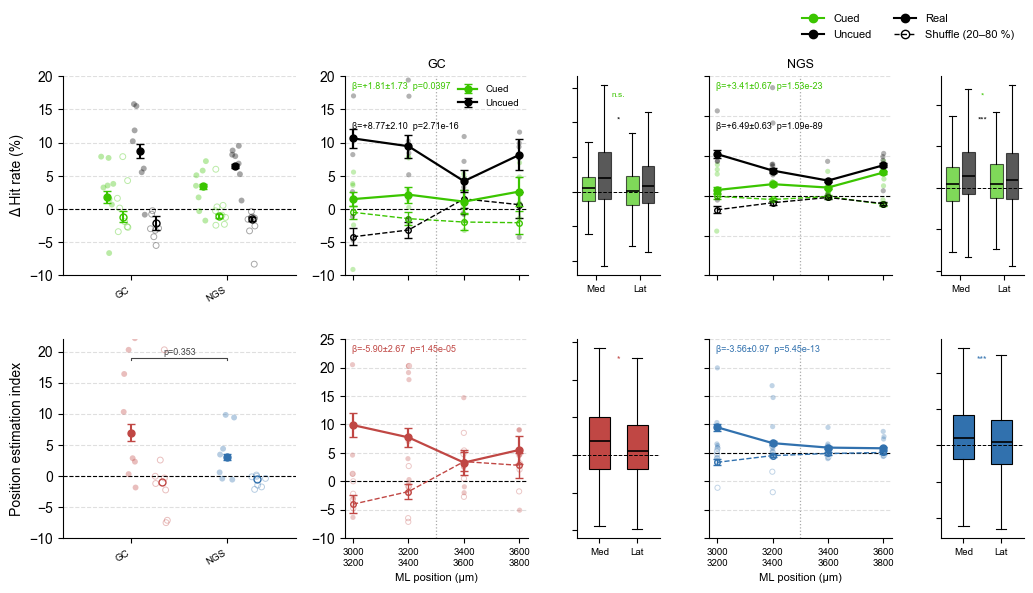

In [26]:
# ── Figure: ML-bin interaction (2 rows × 5 cols) ──────────────────────────────
import time
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import numpy as np

RUN_TESTS    = True
ENT_FILTER   = True
MEDLAT_SPLIT = 3400

_t0 = time.time()
def _elapsed(): return f"{time.time() - _t0:.1f}s"

def _sem(x):
    x = x.dropna()
    return x.std() / np.sqrt(len(x)) if len(x) > 1 else np.nan

def _safe_concat(lst):
    valid = [x for x in lst if x is not None and len(x) > 0]
    return pd.concat(valid, ignore_index=True) if valid else None

def _ent_filter(df):
    if df is None: return None
    if ENT_FILTER and 'brain_region' in df.columns:
        return df[df['brain_region'].str.contains('ENTm', na=False)].copy()
    return df.copy()

def build_records(df):
    rows = []
    for _, r in df.iterrows():
        for cond, col, tt in [('b, label=1','pct_b_1','b'), ('b, label=0','pct_b_0','b'),
                               ('nb, label=1','pct_nb_1','nb'), ('nb, label=0','pct_nb_0','nb')]:
            rows.append({'pct_hits': r[col], 'condition': cond, 'trial_type': tt,
                         'mouse': r['mouse'], 'cluster_id': r.get('cluster_id', np.nan)})
    return pd.DataFrame(rows).dropna(subset=['pct_hits'])

def fit_lmm(df, name):
    import statsmodels.formula.api as smf
    df = df.copy().dropna(subset=['pct_hits'])
    df['anchored'] = df['condition'].str.contains('label=1').astype(float)
    if len(df) < 10:
        print(f"  {name}: too few rows ({len(df)}), skipping")
        return None, np.nan, np.nan, np.nan
    try:
        mfit = smf.mixedlm('pct_hits ~ anchored', df, groups=df['mouse']).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit, mfit.fe_params['anchored'], mfit.bse_fe['anchored'], mfit.pvalues['anchored']
    except Exception as e:
        print(f"  {name}: LMM failed ({e})")
        return None, np.nan, np.nan, np.nan

def _fit_medlat_lmm(cells_plot, value_col, name=''):
    import statsmodels.formula.api as smf
    df = cells_plot[['mouse', value_col, 'SC_x']].copy().dropna(
        subset=[value_col, 'mouse', 'SC_x'])
    df['lateral'] = (df['SC_x'] >= MEDLAT_SPLIT).astype(float)
    if len(df) < 10 or df['mouse'].nunique() < 2:
        return np.nan
    try:
        mfit = smf.mixedlm(f'{value_col} ~ lateral', df, groups=df['mouse']).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit.pvalues['lateral']
    except Exception as e:
        print(f"  medlat LMM {name}: {e}"); return np.nan

def _fit_pi_comparison(cp_a, cp_b, name):
    import statsmodels.formula.api as smf
    df_a = cp_a[['mouse','day','delta_nb','delta_b']].copy()
    df_a['sensitivity'] = df_a['delta_nb'] - df_a['delta_b'];  df_a['group'] = 0
    df_b = cp_b[['mouse','day','delta_nb','delta_b']].copy()
    df_b['sensitivity'] = df_b['delta_nb'] - df_b['delta_b'];  df_b['group'] = 1
    df = pd.concat([df_a, df_b], ignore_index=True).dropna(subset=['sensitivity'])
    df['session'] = df['mouse'].astype(str) + '_' + df['day'].astype(str)
    if len(df) < 10: return np.nan, np.nan
    try:
        mfit = smf.mixedlm('sensitivity ~ group', df, groups=df['mouse'],
                            vc_formula={'session': '0 + C(session)'}).fit(
            reml=False, method='lbfgs', disp=False)
        return mfit.fe_params['group'], mfit.pvalues['group']
    except Exception as e:
        print(f"  {name}: {e}"); return np.nan, np.nan

def _pval_stars(p):
    if np.isnan(p) or p >= 0.05: return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    return '*'

def _pval_str(p):
    s = _pval_stars(p)
    txt = f"p={p:.3g}" if not np.isnan(p) else 'n.s.'
    return f"{s} ({txt})" if s != 'n.s.' else txt

def _draw_bracket(ax, x1, x2, y, text, color='#444444', lw=0.8, fontsize=6.5):
    ylo, yhi = ax.get_ylim()
    tick_h = (yhi - ylo) * 0.012
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h], lw=lw, color=color, clip_on=False)
    ax.text((x1+x2)/2, y + tick_h*0.3, text, ha='center', va='bottom',
            fontsize=fontsize, color=color, clip_on=False)

# ── Ensure NS cells ───────────────────────────────────────────────────────────
if 'NS cells' not in stored_shuf:
    _ns_shuf = shuffled_[shuffled_.cell_identity == 'NS']
    stored_shuf['NS cells'] = {
        'cells_plot': _build_plot_df(others_),
        'shuf_plot':  _build_plot_df(_ns_shuf) if len(_ns_shuf) else None,
    }
    print(f"Added NS cells: {len(others_)} cells")

# ── Colors / labels ───────────────────────────────────────────────────────────
cell_colors_fig = {'Grid cells': gc_color, 'NGS': '#3171ae'}
cell_short_fig  = {'Grid cells': 'GC', 'NGS': 'NGS'}
display_labels  = ['Grid cells', 'NGS']
n_ct            = len(display_labels)

# ── Build ENTm-filtered groups ────────────────────────────────────────────────
print(f"[{_elapsed()}] Building groups (ENT_FILTER={ENT_FILTER}, RUN_TESTS={RUN_TESTS})...")
_src = {}
for ct in ['Grid cells', 'NGS ramp', 'NGS non-ramp', 'NS cells']:
    d = stored_shuf.get(ct, {})
    _src[ct] = {'cells_plot': _ent_filter(d.get('cells_plot')),
                'shuf_plot':  _ent_filter(d.get('shuf_plot'))}

_raw = {}
_raw['Grid cells'] = _src['Grid cells']
_raw['NGS'] = {
    'cells_plot': _safe_concat([_src['NGS ramp']['cells_plot'], _src['NGS non-ramp']['cells_plot']]),
    'shuf_plot':  _safe_concat([_src['NGS ramp']['shuf_plot'],  _src['NGS non-ramp']['shuf_plot']]),
}

for lbl in display_labels:
    n = len(_raw[lbl]['cells_plot']) if _raw[lbl]['cells_plot'] is not None else 0
    print(f"[{_elapsed()}]   {lbl}: {n} neurons")

# ── LMMs — anchoring effect on hit rate ──────────────────────────────────────
_order_rec = ['b, label=1', 'b, label=0', 'nb, label=1', 'nb, label=0']
stored_disp = {}
for cell_label in display_labels:
    cp = _raw[cell_label]['cells_plot']
    sp = _raw[cell_label]['shuf_plot']
    if RUN_TESTS and cp is not None and len(cp) >= 10:
        _df = build_records(cp)
        _df['condition'] = pd.Categorical(_df['condition'], categories=_order_rec, ordered=True)
        print(f"[{_elapsed()}] LMM {cell_label} Cued...")
        _, eff_b,  se_b,  p_b  = fit_lmm(_df[_df['trial_type'] == 'b'],  f'{cell_label} Cued')
        print(f"[{_elapsed()}] LMM {cell_label} Uncued...")
        _, eff_nb, se_nb, p_nb = fit_lmm(_df[_df['trial_type'] == 'nb'], f'{cell_label} Uncued')
    else:
        eff_b = se_b = p_b = eff_nb = se_nb = p_nb = np.nan
    stored_disp[cell_label] = dict(eff_b=eff_b, se_b=se_b, p_b=p_b,
                                   eff_nb=eff_nb, se_nb=se_nb, p_nb=p_nb,
                                   cells_plot=cp, shuf_plot=sp)
    print(f"[{_elapsed()}]   {cell_label}: eff_b={eff_b:.3f} p={p_b:.3g}, eff_nb={eff_nb:.3f} p={p_nb:.3g}")

# ── Shuffle LMMs ─────────────────────────────────────────────────────────────
shuf_lmm = {}
for cell_label in display_labels:
    sp = stored_disp[cell_label]['shuf_plot']
    if RUN_TESTS and sp is not None and len(sp) >= 10:
        df_s = build_records(sp)
        df_s['condition'] = pd.Categorical(df_s['condition'], categories=_order_rec, ordered=True)
        print(f"[{_elapsed()}] Shuffle LMM {cell_label}...")
        _, eff_b_s,  se_b_s,  _ = fit_lmm(df_s[df_s['trial_type'] == 'b'],  f'{cell_label} shuf-b')
        _, eff_nb_s, se_nb_s, _ = fit_lmm(df_s[df_s['trial_type'] == 'nb'], f'{cell_label} shuf-nb')
        shuf_lmm[cell_label] = {'Cued': (eff_b_s, se_b_s), 'Uncued': (eff_nb_s, se_nb_s)}
    else:
        shuf_lmm[cell_label] = {'Cued': (np.nan, np.nan), 'Uncued': (np.nan, np.nan)}

# ── PI-sensitivity interaction LMMs ──────────────────────────────────────────
pi_inter = {}
for cell_label in display_labels:
    if RUN_TESTS:
        d  = stored_disp[cell_label]
        cp = d['cells_plot'].copy() if d['cells_plot'] is not None else None
        sp = d['shuf_plot'].copy()  if d['shuf_plot']  is not None else None
        if cp is not None: cp['sensitivity'] = cp['delta_nb'] - cp['delta_b']
        if sp is not None: sp['sensitivity'] = sp['delta_nb'] - sp['delta_b']
        if cp is not None and sp is not None and len(sp) > 0:
            print(f"[{_elapsed()}]   {cell_label}: fit_scx_interaction_lmm...")
            coef, z, p = fit_scx_interaction_lmm(cp, sp, f'{cell_label} PI-sens', 'sensitivity')
        else:
            coef, z, p = np.nan, np.nan, np.nan
    else:
        coef, z, p = np.nan, np.nan, np.nan
    pi_inter[cell_label] = {'β': coef, 'z': z, 'p': p}
    print(f"[{_elapsed()}]   {cell_label}: β={coef:.3f}, p={p:.3g}")

# ── Pairwise PI: GC vs NGS ────────────────────────────────────────────────────
if RUN_TESTS:
    print(f"[{_elapsed()}] GC vs NGS PI comparison...")
    _gc_ngs_coef, _gc_ngs_p = _fit_pi_comparison(
        stored_disp['Grid cells']['cells_plot'],
        stored_disp['NGS']['cells_plot'], 'GC vs NGS')
else:
    _gc_ngs_coef, _gc_ngs_p = np.nan, np.nan
_pi_comps = {'GC vs NGS': {'coef': _gc_ngs_coef, 'p': _gc_ngs_p}}
print(f"[{_elapsed()}] GC vs NGS: Δ={_gc_ngs_coef:.3f}, p={_gc_ngs_p:.3g}")

# ── x-positions for summary col ───────────────────────────────────────────────
_gap      = 0.7
_x_eff    = {lbl: i * _gap for i, lbl in enumerate(display_labels)}
_xlim_eff = (-0.5, max(_x_eff.values()) + 0.5)

# ── Valid bins ────────────────────────────────────────────────────────────────
_valid_mask = []
for lo, hi in sc_bins:
    _has = any(
        stored_disp[lbl]['cells_plot'] is not None and
        int(((stored_disp[lbl]['cells_plot']['SC_x'] >= lo) &
             (stored_disp[lbl]['cells_plot']['SC_x'] <  hi)).sum()) > 0
        for lbl in display_labels
    )
    _valid_mask.append(_has)
_valid_bins        = [b for b, v in zip(sc_bins,        _valid_mask) if v]
_valid_bin_centers = [c for c, v in zip(sc_bin_centers, _valid_mask) if v]
_valid_bin_labels  = [l for l, v in zip(sc_bin_labels,  _valid_mask) if v]
_xpad_line         = (max(_valid_bin_centers) - min(_valid_bin_centers)) * 0.05
_xlim_line         = (min(_valid_bin_centers) - _xpad_line, max(_valid_bin_centers) + _xpad_line)
print(f"[{_elapsed()}] Valid bins: {len(_valid_bins)}/{len(sc_bins)} "
      f"({_valid_bin_centers[0]}–{_valid_bin_centers[-1]} µm)")

# ── Boxplot helpers ───────────────────────────────────────────────────────────
def _medlat_boxplot_row0(ax, cells_plot, p_b=np.nan, p_nb=np.nan):
    med = cells_plot[cells_plot['SC_x'] <  MEDLAT_SPLIT]
    lat = cells_plot[cells_plot['SC_x'] >= MEDLAT_SPLIT]
    data      = [med['delta_b'].dropna(), med['delta_nb'].dropna(),
                 lat['delta_b'].dropna(), lat['delta_nb'].dropna()]
    positions = [0.0, 0.38, 1.05, 1.43]
    bp_colors = [trial_colors['Cued'], trial_colors['Uncued'],
                 trial_colors['Cued'], trial_colors['Uncued']]
    bp = ax.boxplot(data, positions=positions, widths=0.30, patch_artist=True,
                    showfliers=False, medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    for patch, c in zip(bp['boxes'], bp_colors):
        patch.set_facecolor(c);  patch.set_alpha(0.65)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)
    ax.set_xticks([0.19, 1.24]);  ax.set_xticklabels(['Med', 'Lat'], fontsize=7)
    ax.set_xlim(-0.28, 1.71);  ax.tick_params(labelleft=False)
    sns.despine(ax=ax)
    for p, y_frac, trial_lbl in [(p_b, 0.92, 'Cued'), (p_nb, 0.80, 'Uncued')]:
        if not np.isnan(p):
            ax.text(0.5, y_frac, _pval_stars(p), ha='center', va='top', fontsize=6,
                    color=trial_colors[trial_lbl], transform=ax.transAxes)

def _medlat_boxplot_row1(ax, cells_plot, color, p=np.nan):
    cp = cells_plot.copy()
    cp['sensitivity'] = cp['delta_nb'] - cp['delta_b']
    med = cp[cp['SC_x'] <  MEDLAT_SPLIT]['sensitivity'].dropna()
    lat = cp[cp['SC_x'] >= MEDLAT_SPLIT]['sensitivity'].dropna()
    bp = ax.boxplot([med, lat], positions=[0, 1], widths=0.55, patch_artist=True,
                    showfliers=False, medianprops=dict(color='k', linewidth=1.2),
                    whiskerprops=dict(linewidth=0.8), capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    for patch in bp['boxes']:
        patch.set_facecolor(color);  patch.set_alpha(1)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.7)
    ax.set_xticks([0, 1]);  ax.set_xticklabels(['Med', 'Lat'], fontsize=7)
    ax.set_xlim(-0.6, 1.6);  ax.tick_params(labelleft=False)
    sns.despine(ax=ax)
    if not np.isnan(p):
        ax.text(0.5, 0.92, _pval_stars(p), ha='center', va='top', fontsize=6.5,
                color=color, transform=ax.transAxes)

# ── Figure layout: 2 rows × 5 cols ───────────────────────────────────────────
print(f"[{_elapsed()}] Building figure...")
_lw, _bw = 2.2, 1.0
fig = plt.figure(figsize=(6 + (_lw + _bw) * n_ct, 6.0))
gs  = fig.add_gridspec(
    2, 1 + 2 * n_ct,
    width_ratios=[2.8] + [w for _ in range(n_ct) for w in [_lw, _bw]],
    height_ratios=[2.4, 2.4],
    hspace=0.32, wspace=0.32,
)

# ── Row 0, col 0 — effect size summary ───────────────────────────────────────
ax_eff = fig.add_subplot(gs[0, 0])
for cell_label in display_labels:
    xb = _x_eff[cell_label];  d = stored_disp[cell_label]
    cp = d['cells_plot'];       sp = d['shuf_plot']
    for trial_label, delta_col, eff_key, se_key, xr_off, xs_off in [
        ('Cued',   'delta_b',  'eff_b',  'se_b',  -0.18, -0.06),
        ('Uncued', 'delta_nb', 'eff_nb', 'se_nb', +0.06, +0.18),
    ]:
        color    = trial_colors[trial_label]
        xr, xs_p = xb + xr_off, xb + xs_off
        eff, se  = d[eff_key], d[se_key]
        if not np.isnan(eff):
            ax_eff.errorbar(xr, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, zorder=5)
            am = cp.groupby('mouse')[delta_col].mean().dropna()
            ax_eff.scatter(np.full(len(am), xr) + np.random.uniform(-0.05, 0.05, len(am)),
                           am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
        s_eff, s_se = shuf_lmm[cell_label].get(trial_label, (np.nan, np.nan))
        if not np.isnan(s_eff):
            ax_eff.errorbar(xs_p, s_eff, yerr=(s_se if not np.isnan(s_se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, mfc='none', mec=color, zorder=5)
            if sp is not None:
                am_s = sp.groupby('mouse')[delta_col].mean().dropna()
                ax_eff.scatter(np.full(len(am_s), xs_p) + np.random.uniform(-0.05, 0.05, len(am_s)),
                               am_s, facecolors='none', edgecolors=color, alpha=0.35, s=18, zorder=4, linewidths=0.7)
ax_eff.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_eff.set_xticks([_x_eff[k] for k in display_labels])
ax_eff.set_xticklabels([cell_short_fig[k] for k in display_labels], fontsize=7, rotation=30, ha='right')
ax_eff.set_xlim(*_xlim_eff);  ax_eff.set_ylabel('Δ Hit rate (%)', fontsize=10)
ax_eff.grid(axis='y', linestyle='--', alpha=0.4);  ax_eff.set_ylim(-10, 20)
sns.despine(ax=ax_eff)

# ── Row 1, col 0 — PI summary ────────────────────────────────────────────────
ax_pi = fig.add_subplot(gs[1, 0])
for cell_label in display_labels:
    xb    = _x_eff[cell_label];  d = stored_disp[cell_label]
    cp    = d['cells_plot'];      sp = d['shuf_plot']
    color = cell_colors_fig[cell_label]
    sens_r = d['eff_nb'] - d['eff_b']
    se_r   = (np.sqrt(d['se_nb']**2 + d['se_b']**2)
              if not (np.isnan(d['se_nb']) or np.isnan(d['se_b'])) else np.nan)
    if not np.isnan(sens_r):
        ax_pi.errorbar(xb, sens_r, yerr=(se_r if not np.isnan(se_r) else None),
                       fmt='o', color=color, capsize=3, markersize=5, zorder=5)
        am = cp.assign(sens=cp['delta_nb'] - cp['delta_b']).groupby('mouse')['sens'].mean().dropna()
        ax_pi.scatter(np.full(len(am), xb) + np.random.uniform(-0.07, 0.07, len(am)),
                      am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
    s_eff_b,  _ = shuf_lmm[cell_label].get('Cued',   (np.nan, np.nan))
    s_eff_nb, _ = shuf_lmm[cell_label].get('Uncued', (np.nan, np.nan))
    sens_s = s_eff_nb - s_eff_b
    if not np.isnan(sens_s):
        ax_pi.errorbar(xb + 0.22, sens_s, fmt='o', color=color, capsize=3,
                       markersize=5, mfc='none', mec=color, zorder=5)
        if sp is not None:
            am_s = sp.assign(sens=sp['delta_nb'] - sp['delta_b']).groupby('mouse')['sens'].mean().dropna()
            ax_pi.scatter(np.full(len(am_s), xb + 0.22) + np.random.uniform(-0.06, 0.06, len(am_s)),
                          am_s, facecolors='none', edgecolors=color, alpha=0.35, s=18, zorder=4, linewidths=0.7)
ax_pi.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_pi.set_xticks([_x_eff[k] for k in display_labels])
ax_pi.set_xticklabels([cell_short_fig[k] for k in display_labels], fontsize=7, rotation=30, ha='right')
ax_pi.set_xlim(*_xlim_eff);  ax_pi.set_ylabel('Position estimation index', fontsize=10)
ax_pi.grid(axis='y', linestyle='--', alpha=0.4)
_bk_y0 = 19.0;  ax_pi.set_ylim(-10, _bk_y0 + 3.0)
_draw_bracket(ax_pi, _x_eff['Grid cells'], _x_eff['NGS'], _bk_y0, _pval_str(_pi_comps['GC vs NGS']['p']))
sns.despine(ax=ax_pi)

# ── Per-cell-type columns (cols 1–4) ─────────────────────────────────────────
print(f"[{_elapsed()}] Plotting per-cell-type columns...")
for col_i, cell_label in enumerate(display_labels):
    print(f"[{_elapsed()}]   {cell_label} ({col_i+1}/{n_ct})...")
    col_line = 1 + 2 * col_i;  col_box = 2 + 2 * col_i

    ax_top     = fig.add_subplot(gs[0, col_line])
    ax_top_box = fig.add_subplot(gs[0, col_box])
    ax_bot     = fig.add_subplot(gs[1, col_line], sharex=ax_top)
    ax_bot_box = fig.add_subplot(gs[1, col_box])

    d          = stored_disp[cell_label]
    cells_plot = d['cells_plot'].copy()
    shuf_plot  = d['shuf_plot'].copy() if d['shuf_plot'] is not None else None
    color      = cell_colors_fig[cell_label]

    # ── Med/Lat LMMs ─────────────────────────────────────────────────────
    if RUN_TESTS and cells_plot is not None and 'SC_x' in cells_plot.columns:
        p_b_ml  = _fit_medlat_lmm(cells_plot, 'delta_b',  f'{cell_label} Cued')
        p_nb_ml = _fit_medlat_lmm(cells_plot, 'delta_nb', f'{cell_label} Uncued')
        _cp_tmp = cells_plot.copy();  _cp_tmp['sensitivity'] = _cp_tmp['delta_nb'] - _cp_tmp['delta_b']
        p_pi_ml = _fit_medlat_lmm(_cp_tmp, 'sensitivity', f'{cell_label} PI')
    else:
        p_b_ml = p_nb_ml = p_pi_ml = np.nan

    # ── Row 0: ML-bin Δ hit rate ──────────────────────────────────────────
    for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
        tc = trial_colors[trial_label]
        means, sems, xs_c = [], [], []
        for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
            bm  = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
            sub = cells_plot[bm][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
            am = cells_plot[bm].groupby('mouse')[delta_col].mean().dropna()
            ax_top.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                           am, color=tc, alpha=0.30, s=14, zorder=4, edgecolor='none')
        ax_top.errorbar(xs_c, means, yerr=sems, fmt='o-', color=tc,
                        capsize=3, linewidth=1.6, markersize=5, zorder=5, label=trial_label)
        if shuf_plot is not None:
            s_means, s_sems = [], []
            for (lo, hi) in _valid_bins:
                sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)][delta_col].dropna()
                s_means.append(sub.mean()); s_sems.append(_sem(sub))
            ax_top.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=tc,
                            capsize=3, linewidth=1.0, markersize=4, mfc='none', mec=tc, zorder=3)

    # ── LMM annotation for hit rates (both GC and NGS) ───────────────────
    if RUN_TESTS:
        for ann_i, (trial_label, eff_key, se_key, p_key) in enumerate([
            ('Cued',   'eff_b',  'se_b',  'p_b'),
            ('Uncued', 'eff_nb', 'se_nb', 'p_nb'),
        ]):
            bv, se_v, pv = d[eff_key], d[se_key], d[p_key]
            if not np.isnan(bv):
                tc    = trial_colors[trial_label]
                se_str = f"±{1.96*se_v:.2f}" if not np.isnan(se_v) else ""
                p_str  = f"  p={pv:.3g}" if not np.isnan(pv) else ""
                ax_top.text(0.04, 0.97 - ann_i * 0.20, f"β={bv:+.2f}{se_str}{p_str}",
                            ha='left', va='top', fontsize=6.5, color=tc,
                            transform=ax_top.transAxes)

    ax_top.axvline(MEDLAT_SPLIT, color='#aaaaaa', linestyle=':', linewidth=0.9)
    ax_top.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_top.set_xlim(*_xlim_line)
    ax_top.set_title(cell_short_fig[cell_label], fontsize=9)
    ax_top.grid(axis='y', linestyle='--', alpha=0.4)
    ax_top.tick_params(labelbottom=False)
    if col_i == 0:
        ax_top.legend(fontsize=7, frameon=False, loc='upper right')
        ax_top.set_ylim(-10, 20)
    else:
        ax_top.set_ylim(-20, 30);  plt.setp(ax_top.get_yticklabels(), visible=False)
    sns.despine(ax=ax_top)

    _medlat_boxplot_row0(ax_top_box, cells_plot, p_b=p_b_ml, p_nb=p_nb_ml)

    # ── Row 1: ML-bin PI ─────────────────────────────────────────────────
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs_c = [], [], []
    for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
        bm  = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
        sub = cells_plot[bm]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
        am = cells_plot[bm].groupby('mouse')['sensitivity'].mean().dropna()
        ax_bot.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                       am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
    ax_bot.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                    capsize=3, linewidth=1.6, markersize=5, zorder=5)
    if shuf_plot is not None:
        shuf_plot['sensitivity'] = shuf_plot['delta_nb'] - shuf_plot['delta_b']
        s_means, s_sems = [], []
        for (lo, hi), center in zip(_valid_bins, _valid_bin_centers):
            bm_s = (shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)
            sub  = shuf_plot[bm_s]['sensitivity'].dropna()
            s_means.append(sub.mean()); s_sems.append(_sem(sub))
            am_s = shuf_plot[bm_s].groupby('mouse')['sensitivity'].mean().dropna()
            ax_bot.scatter(np.full(len(am_s), center) + np.random.uniform(-2, 2, len(am_s)),
                           am_s, facecolors='none', edgecolors=color, alpha=0.30, s=14, zorder=3, linewidths=0.7)
        ax_bot.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                        capsize=3, linewidth=1.0, markersize=4, mfc='none', mec=color, zorder=3)
    pi_res = pi_inter.get(cell_label, {})
    pi_bv, pi_zv, pi_pv = pi_res.get('β', np.nan), pi_res.get('z', np.nan), pi_res.get('p', np.nan)
    if not np.isnan(pi_bv):
        pi_se  = abs(pi_bv / pi_zv) if (not np.isnan(pi_zv) and pi_zv != 0) else np.nan
        pi_ann = (f"β={pi_bv:+.2f}" + (f"±{1.96*pi_se:.2f}" if not np.isnan(pi_se) else "") + f"  p={pi_pv:.3g}")
        ax_bot.text(0.04, 0.97, pi_ann, ha='left', va='top', fontsize=6.5,
                    color=color, transform=ax_bot.transAxes)
    ax_bot.axvline(MEDLAT_SPLIT, color='#aaaaaa', linestyle=':', linewidth=0.9)
    ax_bot.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_bot.set_xticks(_valid_bin_centers)
    ax_bot.set_xticklabels(_valid_bin_labels, fontsize=7)
    ax_bot.set_xlabel('ML position (µm)', fontsize=8)
    ax_bot.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_bot.set_ylim(-10, 25)
    else:
        ax_bot.set_ylim(-30, 40);  plt.setp(ax_bot.get_yticklabels(), visible=False)
    sns.despine(ax=ax_bot)

    _medlat_boxplot_row1(ax_bot_box, cells_plot, color, p=p_pi_ml)

# ── Legend ────────────────────────────────────────────────────────────────────
print(f"[{_elapsed()}] Saving...")
cued_line   = mlines.Line2D([], [], color=trial_colors['Cued'],   marker='o', linewidth=1.5, label='Cued')
uncued_line = mlines.Line2D([], [], color=trial_colors['Uncued'], marker='o', linewidth=1.5, label='Uncued')
real_line   = mlines.Line2D([], [], color='k', marker='o', linewidth=1.5, label='Real')
shuf_line   = mlines.Line2D([], [], color='k', marker='o', linestyle='--',
                             linewidth=1.0, mfc='none', label='Shuffle (20–80 %)')
fig.legend(handles=[cued_line, uncued_line, real_line, shuf_line],
           fontsize=8, frameon=False, loc='upper right', bbox_to_anchor=(0.9, 1.0), ncol=2)
plt.savefig('ml_interaction_summary_ENTm.pdf', dpi=300, bbox_inches='tight')
plt.show()


[738.1s] Building figure layout...
[738.2s] Plotting per-cell-type columns...
[738.2s]   Column 1/5: All cells
[738.2s]   Column 2/5: Grid cells
[738.3s]   Column 3/5: NGS non-ramp
[738.3s]   Column 4/5: NGS ramp
[738.3s]   Column 5/5: NS cells
[738.4s] Adding legend and saving...


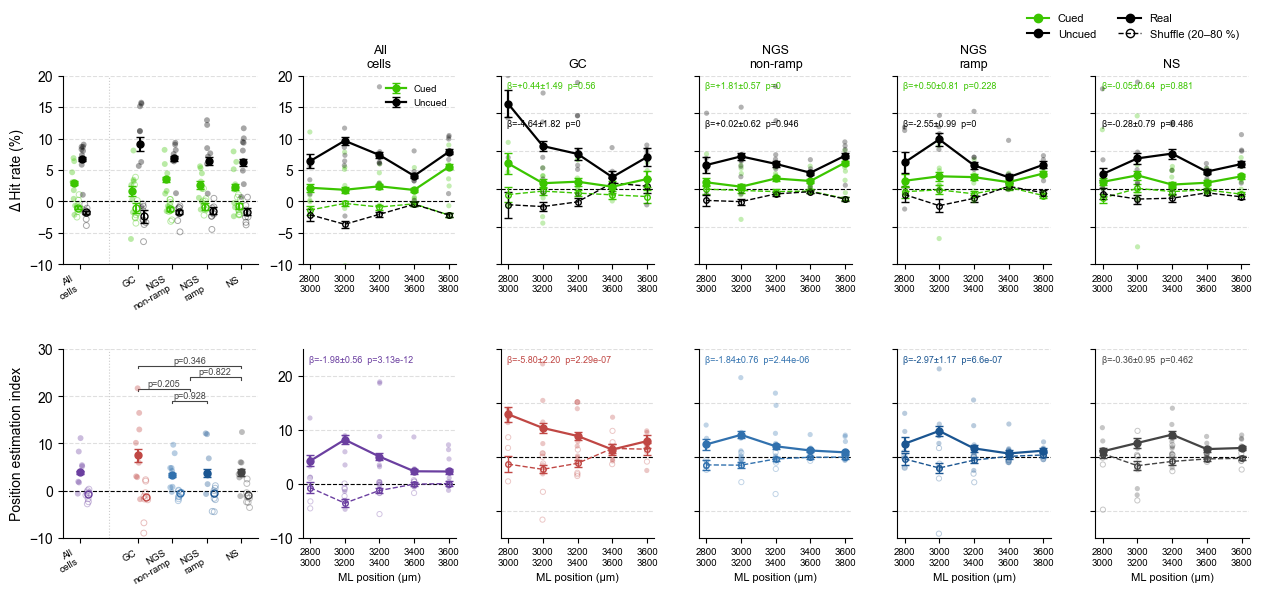

In [15]:


# ── x-positions for col-0 summary panels ─────────────────────────────────────
_gap      = 0.7
_x_eff    = {lbl: (0.0 if lbl == 'All cells' else i + _gap)
             for i, lbl in enumerate(all_cell_labels)}
_xlim_eff = (-0.5, max(_x_eff.values()) + 0.5)
_sep_x    = 0.85

# ── Figure layout: 2 rows × (1 + n_ct) cols ──────────────────────────────────
print(f"[{_elapsed()}] Building figure layout...")
fig = plt.figure(figsize=(2.8 + 2.5 * n_ct, 6.0))
gs  = fig.add_gridspec(
    2, 1 + n_ct,
    width_ratios=[2.8] + [2.2] * n_ct,
    height_ratios=[2.4, 2.4],
    hspace=0.45, wspace=0.28,
)

# ── Row 0, col 0 — effect size summary ───────────────────────────────────────
ax_eff = fig.add_subplot(gs[0, 0])

for cell_label in all_cell_labels:
    xb = _x_eff[cell_label]
    d  = stored_shuf_local[cell_label]
    cp = d['cells_plot']
    sp = d['shuf_plot']

    for trial_label, delta_col, eff_key, se_key, xr_off, xs_off in [
        ('Cued',   'delta_b',  'eff_b',  'se_b',  -0.18, -0.06),
        ('Uncued', 'delta_nb', 'eff_nb', 'se_nb', +0.06, +0.18),
    ]:
        color    = trial_colors[trial_label]
        xr, xs_p = xb + xr_off, xb + xs_off
        eff, se  = d[eff_key], d[se_key]
        if not np.isnan(eff):
            ax_eff.errorbar(xr, eff, yerr=(se if not np.isnan(se) else None),
                            fmt='o', color=color, capsize=3, markersize=5, zorder=5)
            am = cp.groupby('mouse')[delta_col].mean().dropna()
            ax_eff.scatter(np.full(len(am), xr) + np.random.uniform(-0.05, 0.05, len(am)),
                           am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
        s_eff, s_se = shuf_lmm[cell_label].get(trial_label, (np.nan, np.nan))
        if not np.isnan(s_eff):
            ax_eff.errorbar(xs_p, s_eff, yerr=(s_se if not np.isnan(s_se) else None),
                            fmt='o', color=color, capsize=3, markersize=5,
                            mfc='none', mec=color, zorder=5)
            if sp is not None:
                am_s = sp.groupby('mouse')[delta_col].mean().dropna()
                ax_eff.scatter(
                    np.full(len(am_s), xs_p) + np.random.uniform(-0.05, 0.05, len(am_s)),
                    am_s, facecolors='none', edgecolors=color,
                    alpha=0.35, s=18, zorder=4, linewidths=0.7)

ax_eff.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_eff.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_eff.set_xticks([_x_eff[k] for k in all_cell_labels])
ax_eff.set_xticklabels([cell_short_fig.get(k, k) for k in all_cell_labels],
                       fontsize=7, rotation=30, ha='right')
ax_eff.set_xlim(*_xlim_eff)
ax_eff.set_ylabel('Δ Hit rate (%)', fontsize=10)
ax_eff.grid(axis='y', linestyle='--', alpha=0.4)
ax_eff.set_ylim(-10, 20)  # Set y-limits for first column
sns.despine(ax=ax_eff)

# ── Row 1, col 0 — Positional estimation index summary ─────────────────────────────────────
ax_pi = fig.add_subplot(gs[1, 0])

for cell_label in all_cell_labels:
    xb     = _x_eff[cell_label]
    d      = stored_shuf_local[cell_label]
    cp     = d['cells_plot']
    sp     = d['shuf_plot']
    color  = cell_colors_fig[cell_label]
    sens_r = d['eff_nb'] - d['eff_b']
    se_r   = (np.sqrt(d['se_nb']**2 + d['se_b']**2)
              if not (np.isnan(d['se_nb']) or np.isnan(d['se_b'])) else np.nan)
    if not np.isnan(sens_r):
        ax_pi.errorbar(xb, sens_r, yerr=(se_r if not np.isnan(se_r) else None),
                       fmt='o', color=color, capsize=3, markersize=5, zorder=5)
        am = cp.assign(sens=cp['delta_nb'] - cp['delta_b']).groupby('mouse')['sens'].mean().dropna()
        ax_pi.scatter(np.full(len(am), xb) + np.random.uniform(-0.07, 0.07, len(am)),
                      am, color=color, alpha=0.35, s=18, zorder=4, edgecolor='none')
    s_eff_b,  _ = shuf_lmm[cell_label].get('Cued',   (np.nan, np.nan))
    s_eff_nb, _ = shuf_lmm[cell_label].get('Uncued', (np.nan, np.nan))
    sens_s = s_eff_nb - s_eff_b
    if not np.isnan(sens_s):
        ax_pi.errorbar(xb + 0.22, sens_s, fmt='o', color=color, capsize=3,
                       markersize=5, mfc='none', mec=color, zorder=5)
        if sp is not None:
            am_s = sp.assign(sens=sp['delta_nb'] - sp['delta_b']).groupby('mouse')['sens'].mean().dropna()
            ax_pi.scatter(
                np.full(len(am_s), xb + 0.22) + np.random.uniform(-0.06, 0.06, len(am_s)),
                am_s, facecolors='none', edgecolors=color,
                alpha=0.35, s=18, zorder=4, linewidths=0.7)

ax_pi.axvline(_sep_x, color='#cccccc', linestyle=':', linewidth=0.8, zorder=0)
ax_pi.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_pi.set_xticks([_x_eff[k] for k in all_cell_labels])
ax_pi.set_xticklabels([cell_short_fig.get(k, k) for k in all_cell_labels],
                      fontsize=7, rotation=30, ha='right')
ax_pi.set_xlim(*_xlim_eff)
ax_pi.set_ylabel("Position estimation index", fontsize=10)
ax_pi.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(ax=ax_pi)
# ── Pairwise bracket annotations on ax_pi ────────────────────────────────────
def _pval_stars(p):
    if np.isnan(p) or p >= 0.05: return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    return '*'

def _draw_bracket(ax, x1, x2, y, text, color='#444444', lw=0.8, fontsize=6.5):
    ylo, yhi = ax.get_ylim()
    tick_h = (yhi - ylo) * 0.012
    ax.plot([x1, x1, x2, x2], [y - tick_h, y, y, y - tick_h],
            lw=lw, color=color, clip_on=False)
    ax.text((x1 + x2) / 2, y + tick_h * 0.3, text,
            ha='center', va='bottom', fontsize=fontsize, color=color, clip_on=False)

_x_gc      = _x_eff['Grid cells']
_x_ngs_r   = _x_eff['NGS ramp']
_x_ngs_nr  = _x_eff['NGS non-ramp']
_x_ngs_mid = (_x_ngs_r + _x_ngs_nr) / 2
_x_ns      = _x_eff['NS cells']

_bk_y0  = 19.0
_bk_dy  = 2.5
ax_pi.set_ylim(-10, _bk_y0 + 4 * _bk_dy + 1.0)

for _bk_i, (_cmp_name, _bk_x1, _bk_x2) in enumerate([
    ('NGS ramp vs nr', _x_ngs_nr,  _x_ngs_r),
    ('GC vs NGS',      _x_gc,      _x_ngs_mid),
    ('NGS vs NS',      _x_ngs_mid, _x_ns),
    ('GC vs NS',       _x_gc,      _x_ns),
]):
    _pval  = _pi_comps[_cmp_name]['p']
    _stars = _pval_stars(_pval)
    _txt   = f"p={_pval:.3g}" if not np.isnan(_pval) else 'n.s.'
    if _stars != 'n.s.':
        _txt = f"{_stars} ({_txt})"
    _draw_bracket(ax_pi, _bk_x1, _bk_x2, _bk_y0 + _bk_i * _bk_dy, _txt)

# ── Per-cell-type columns: rows 0 and 1 ──────────────────────────────────────
print(f"[{_elapsed()}] Plotting per-cell-type columns...")
for col_i, cell_label in enumerate(all_cell_labels):
    print(f"[{_elapsed()}]   Column {col_i+1}/{n_ct}: {cell_label}")
    ax_top = fig.add_subplot(gs[0, col_i + 1])
    ax_bot = fig.add_subplot(gs[1, col_i + 1])
 
    d          = stored_shuf_local[cell_label]
    cells_plot = d['cells_plot'].copy()
    shuf_plot  = d['shuf_plot'].copy() if d['shuf_plot'] is not None else None

    # ── Row 0: ML-bin Cued + Uncued ──────────────────────────────────────
    for trial_label, delta_col in [('Cued', 'delta_b'), ('Uncued', 'delta_nb')]:
        color = trial_colors[trial_label]
        means, sems, xs_c = [], [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            bin_mask = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
            sub = cells_plot[bin_mask][delta_col].dropna()
            means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
            am = cells_plot[bin_mask].groupby('mouse')[delta_col].mean().dropna()
            ax_top.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                           am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
        ax_top.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                        capsize=3, linewidth=1.6, markersize=5, zorder=5, label=trial_label)
        if shuf_plot is not None:
            s_means, s_sems = [], []
            for (lo, hi), center in zip(sc_bins, sc_bin_centers):
                sub = shuf_plot[(shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)][delta_col].dropna()
                s_means.append(sub.mean()); s_sems.append(_sem(sub))
            ax_top.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                            capsize=3, linewidth=1.0, markersize=4,
                            mfc='none', mec=color, zorder=3)

    if cell_label != 'All cells':
        for ann_i, trial_label in enumerate(['Cued', 'Uncued']):
            rm = results_df[(results_df['Cell type']  == cell_label) &
                            (results_df['Trial type'] == trial_label)]
            if len(rm):
                r      = rm.iloc[0]
                bv, zv = r['β (SC_x × real)'], r['z']
                pv     = r['p']
                se_v   = abs(bv / zv) if (not np.isnan(zv) and zv != 0) else np.nan
                color  = trial_colors[trial_label]
                annot  = (f"β={bv:+.2f}" +
                          (f"±{1.96*se_v:.2f}" if not np.isnan(se_v) else "") +
                          f"  p={pv:.3g}")
                ax_top.text(0.04, 0.97 - ann_i * 0.20, annot,
                            ha='left', va='top', fontsize=6.5, color=color,
                            transform=ax_top.transAxes)

    ax_top.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_top.set_xticks(sc_bin_centers)
    ax_top.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_top.set_title(cell_short_fig.get(cell_label, cell_label), fontsize=9)
    ax_top.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_top.legend(fontsize=7, frameon=False, loc='upper right')
        ax_top.set_ylim(-10, 20)  # First column y-lim for delta hit rate
        ax_top.set_yticklabels(ax_top.get_yticklabels())
    else:
        ax_top.set_ylim(-20, 30)  # Other columns y-lim for delta hit rate
        plt.setp(ax_top.get_yticklabels(), visible=False)
    sns.despine(ax=ax_top)

    # ── Row 1: Positional estimation index per bin ────────────────────────
    color = cell_colors_fig[cell_label]
    cells_plot['sensitivity'] = cells_plot['delta_nb'] - cells_plot['delta_b']
    means, sems, xs_c = [], [], []
    for (lo, hi), center in zip(sc_bins, sc_bin_centers):
        bin_mask = (cells_plot['SC_x'] >= lo) & (cells_plot['SC_x'] < hi)
        sub = cells_plot[bin_mask]['sensitivity'].dropna()
        means.append(sub.mean()); sems.append(_sem(sub)); xs_c.append(center)
        am = cells_plot[bin_mask].groupby('mouse')['sensitivity'].mean().dropna()
        ax_bot.scatter(np.full(len(am), center) + np.random.uniform(-2, 2, len(am)),
                       am, color=color, alpha=0.30, s=14, zorder=4, edgecolor='none')
    ax_bot.errorbar(xs_c, means, yerr=sems, fmt='o-', color=color,
                    capsize=3, linewidth=1.6, markersize=5, zorder=5)

    if shuf_plot is not None:
        shuf_plot['sensitivity'] = shuf_plot['delta_nb'] - shuf_plot['delta_b']
        s_means, s_sems = [], []
        for (lo, hi), center in zip(sc_bins, sc_bin_centers):
            bm_s = (shuf_plot['SC_x'] >= lo) & (shuf_plot['SC_x'] < hi)
            sub  = shuf_plot[bm_s]['sensitivity'].dropna()
            s_means.append(sub.mean()); s_sems.append(_sem(sub))
            am_s = shuf_plot[bm_s].groupby('mouse')['sensitivity'].mean().dropna()
            ax_bot.scatter(np.full(len(am_s), center) + np.random.uniform(-2, 2, len(am_s)),
                           am_s, facecolors='none', edgecolors=color,
                           alpha=0.30, s=14, zorder=3, linewidths=0.7)
        ax_bot.errorbar(xs_c, s_means, yerr=s_sems, fmt='o--', color=color,
                        capsize=3, linewidth=1.0, markersize=4,
                        mfc='none', mec=color, zorder=3)

    pi_res = pi_inter.get(cell_label, {})
    pi_bv  = pi_res.get('β', np.nan)
    pi_zv  = pi_res.get('z', np.nan)
    pi_pv  = pi_res.get('p', np.nan)
    if not np.isnan(pi_bv):
        pi_se  = abs(pi_bv / pi_zv) if (not np.isnan(pi_zv) and pi_zv != 0) else np.nan
        pi_ann = (f"β={pi_bv:+.2f}" +
                  (f"±{1.96*pi_se:.2f}" if not np.isnan(pi_se) else "") +
                  f"  p={pi_pv:.3g}")
        ax_bot.text(0.04, 0.97, pi_ann, ha='left', va='top', fontsize=6.5,
                    color=color, transform=ax_bot.transAxes)

    ax_bot.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax_bot.set_xticks(sc_bin_centers)
    ax_bot.set_xticklabels(sc_bin_labels, fontsize=7)
    ax_bot.set_xlabel('ML position (µm)', fontsize=8)
    ax_bot.grid(axis='y', linestyle='--', alpha=0.4)
    if col_i == 0:
        ax_bot.set_ylim(-10, 25)  # First column y-lim for position estimation index
        ax_bot.set_yticklabels(ax_bot.get_yticklabels())
    else:
        ax_bot.set_ylim(-30, 40)  # Other columns y-lim for position estimation index
        plt.setp(ax_bot.get_yticklabels(), visible=False)
    sns.despine(ax=ax_bot)

# ── Legend ────────────────────────────────────────────────────────────────────────────
print(f"[{_elapsed()}] Adding legend and saving...")
cued_line   = mlines.Line2D([], [], color=trial_colors['Cued'],   marker='o',
                             linewidth=1.5, label='Cued')
uncued_line = mlines.Line2D([], [], color=trial_colors['Uncued'], marker='o',
                             linewidth=1.5, label='Uncued')
real_line   = mlines.Line2D([], [], color='k', marker='o',
                             linewidth=1.5, label='Real')
shuf_line   = mlines.Line2D([], [], color='k', marker='o', linestyle='--',
                             linewidth=1.0, mfc='none', label='Shuffle (20–80 %)')
fig.legend(handles=[cued_line, uncued_line, real_line, shuf_line],
           fontsize=8, frameon=False, loc='upper right',
           bbox_to_anchor=(0.9, 1.0), ncol=2)
plt.savefig('ml_interaction_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()

Metrics built for 8926 cells
cell_identity
NGS-nonramp    4501
NS             2195
NGS-ramp       1513
GC              717


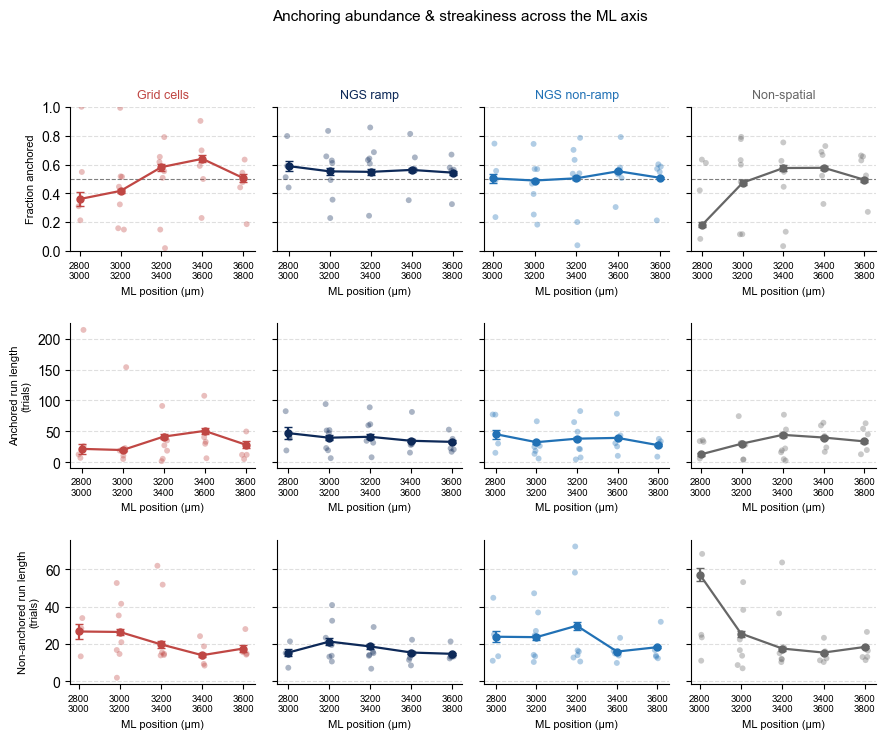

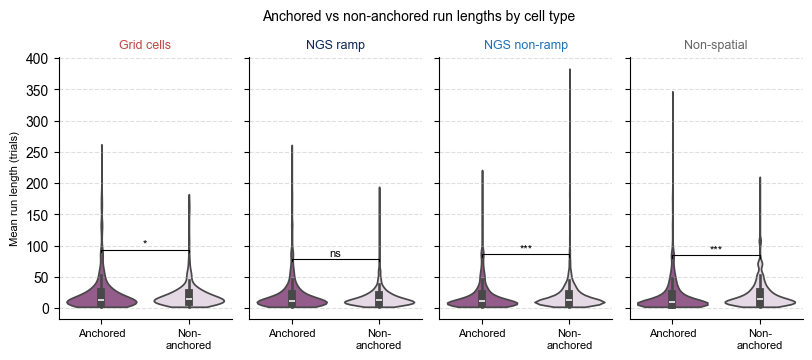

In [24]:

# ── ML-axis: anchoring abundance and streakiness ──────────────────────────────
# For each cell in all_, compute:
#   frac_anchored      – fraction of trials classified as task-anchored
#   streak_all         – mean run length of consecutive same-label blocks
#   streak_anchored    – mean run length of consecutive anchored (1) blocks only
#   streak_non_anch    – mean run length of consecutive non-anchored (0) blocks only
#
# Then bin by SC_x (medial→lateral) and compare across cell types.

import json
from itertools import groupby
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# ── Helper ────────────────────────────────────────────────────────────────────
def _mean_run_length(labels, target_val=None):
    """Mean length of consecutive runs. If target_val is given, only runs of that value."""
    runs = [(k, sum(1 for _ in g)) for k, g in groupby(labels)]
    lengths = [n for k, n in runs if (target_val is None or k == target_val)]
    return float(np.mean(lengths)) if lengths else np.nan

def _sem(x):
    x = x.dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

# ── Build per-cell metrics ────────────────────────────────────────────────────
_rows = []
for _, row in all_.iterrows():
    ta_json = row.get('task_anchored_labels')
    if pd.isna(ta_json):
        continue
    try:
        labels = np.array(json.loads(ta_json), dtype=int)
    except Exception:
        continue
    if len(labels) == 0:
        continue

    # Resolve SC_x coordinate (absolute value → medial = low, lateral = high)
    sc_x = np.nan
    for col in ('SC_x', 'coord_SCs_x'):
        if col in row.index and not pd.isna(row[col]):
            sc_x = float(np.abs(row[col]))
            break
    if np.isnan(sc_x):
        continue

    _rows.append({
        'cell_identity':  row.get('cell_identity', 'Unknown'),
        'mouse':          row.get('mouse'),
        'day':            row.get('day'),
        'cluster_id':     row.get('cluster_id'),
        'SC_x':           sc_x,
        'n_trials':       len(labels),
        'frac_anchored':  float(np.mean(labels == 1)),
        'streak_all':     _mean_run_length(labels),
        'streak_anchored': _mean_run_length(labels, 1),
        'streak_non_anch': _mean_run_length(labels, 0),
    })

metrics_df = pd.DataFrame(_rows)
print(f"Metrics built for {len(metrics_df)} cells")
print(metrics_df['cell_identity'].value_counts().to_string())

# ── Cell-type appearance ──────────────────────────────────────────────────────
_ct_order  = ['GC', 'NGS-ramp', 'NGS-nonramp', 'NS']
_ct_colors = {'GC': gc_color, 'NGS-ramp': ngs_color_dark, 'NGS-nonramp': ngs_color, 'NS': '#666666'}
_ct_labels = {'GC': 'Grid cells', 'NGS-ramp': 'NGS ramp', 'NGS-nonramp': 'NGS non-ramp', 'NS': 'Non-spatial'}

# Use same SC_x bins as rest of notebook
_sc_bins    = [(2800, 3000), (3000, 3200), (3200, 3400), (3400, 3600), (3600, 3800)]
_sc_centers = [2900, 3100, 3300, 3500, 3700]
_sc_labels  = ['2800\n3000', '3000\n3200', '3200\n3400', '3400\n3600', '3600\n3800']
_jitter     = 18   # µm jitter for per-mouse scatter

# ── Figure 1: abundance and streakiness across the ML axis ───────────────────
_metrics    = ['frac_anchored', 'streak_anchored', 'streak_non_anch']
_ylabels    = ['Fraction anchored', 'Anchored run length\n(trials)', 'Non-anchored run length\n(trials)']
_ylims      = [(0, 1), None, None]
_hlines     = [0.5, None, None]   # dashed reference line

n_ct = len(_ct_order)
fig1, axes1 = plt.subplots(
    3, n_ct, figsize=(2.6 * n_ct, 7.5), sharey='row',
    gridspec_kw={'hspace': 0.50, 'wspace': 0.12},
)
fig1.suptitle('Anchoring abundance & streakiness across the ML axis', fontsize=11, y=1.01)

for col_i, ct in enumerate(_ct_order):
    color = _ct_colors[ct]
    sub   = metrics_df[metrics_df['cell_identity'] == ct]

    for row_i, (metric, ylabel, ylim, href) in enumerate(
            zip(_metrics, _ylabels, _ylims, _hlines)):
        ax = axes1[row_i, col_i]

        # Bin means ± SEM
        means, sems, xs = [], [], []
        for (lo, hi), center in zip(_sc_bins, _sc_centers):
            vals = sub[(sub['SC_x'] >= lo) & (sub['SC_x'] < hi)][metric].dropna()
            means.append(vals.mean() if len(vals) else np.nan)
            sems.append(_sem(vals))
            xs.append(center)
        ax.errorbar(xs, means, yerr=sems, fmt='o-', color=color,
                    capsize=3, linewidth=1.6, markersize=5, zorder=5)

        # Per-mouse means as jittered scatter
        for (lo, hi), center in zip(_sc_bins, _sc_centers):
            bm = sub[(sub['SC_x'] >= lo) & (sub['SC_x'] < hi)]
            am = bm.groupby('mouse')[metric].mean().dropna()
            ax.scatter(
                np.full(len(am), center) + np.random.uniform(-_jitter, _jitter, len(am)),
                am, color=color, alpha=0.35, s=18, edgecolor='none', zorder=4,
            )

        if href is not None:
            ax.axhline(href, color='k', ls='--', lw=0.8, alpha=0.5)
        if ylim is not None:
            ax.set_ylim(*ylim)
        if row_i == 0:
            ax.set_title(_ct_labels[ct], fontsize=9, color=color)
        ax.set_xticks(_sc_centers)
        ax.set_xticklabels(_sc_labels, fontsize=7)
        ax.set_xlabel('ML position (µm)', fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        sns.despine(ax=ax)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)

plt.savefig('anchoring_ml_axis_abundance_streakiness.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 2: anchored vs non-anchored run lengths — violin comparison ────────
fig2, axes2 = plt.subplots(
    1, n_ct, figsize=(2.4 * n_ct, 3.4), sharey=True,
    gridspec_kw={'wspace': 0.10},
)
fig2.suptitle('Anchored vs non-anchored run lengths by cell type', fontsize=10, y=1.02)

for col_i, ct in enumerate(_ct_order):
    ax    = axes2[col_i]
    color = _ct_colors[ct]
    sub   = metrics_df[metrics_df['cell_identity'] == ct].dropna(
        subset=['streak_anchored', 'streak_non_anch']
    )

    long_df = pd.DataFrame({
        'run_length': pd.concat([sub['streak_anchored'], sub['streak_non_anch']], ignore_index=True),
        'state':      ['Anchored'] * len(sub) + ['Non-anchored'] * len(sub),
    })
    sns.violinplot(
        data=long_df, x='state', y='run_length', ax=ax,
        palette={'Anchored': '#9d5391', 'Non-anchored': '#e7d7e8'},
        inner='box', cut=0,
    )

    # Annotate with Mann-Whitney U p-value
    anch    = sub['streak_anchored'].dropna()
    nonanch = sub['streak_non_anch'].dropna()
    if len(anch) >= 5 and len(nonanch) >= 5:
        _, pv = mannwhitneyu(anch, nonanch, alternative='two-sided')
        sig   = '***' if pv < 0.001 else '**' if pv < 0.01 else '*' if pv < 0.05 else 'ns'
        y_top = long_df['run_length'].quantile(0.97)
        ax.plot([0, 0, 1, 1], [y_top, y_top * 1.05, y_top * 1.05, y_top],
                color='k', linewidth=0.8)
        ax.text(0.5, y_top * 1.06, sig, ha='center', va='bottom', fontsize=8)

    ax.set_title(_ct_labels[ct], fontsize=9, color=color)
    ax.set_xlabel('')
    ax.set_xticklabels(['Anchored', 'Non-\nanchored'], fontsize=8)
    if col_i == 0:
        ax.set_ylabel('Mean run length (trials)', fontsize=8)
    else:
        ax.set_ylabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(ax=ax)

plt.savefig('anchoring_run_length_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()
